# F1 Cornering Classification

This notebook contains only the active modelling pipeline:

1. Load the existing manifests and fixed session split.
2. Train or load the CNN.
3. Train the delta-only logistic regression.
4. Generate lap-level CNN probabilities.
5. Compare CNN aggregation methods.
6. Fuse CNN and delta probabilities on the validation set.

The test set remains untouched during model development.


In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from pathlib import Path
from PIL import Image

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    ConfusionMatrixDisplay,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


## 1. Configuration


In [19]:
batch_size = 16
num_epochs = 15
learning_rate = 0.0001
seed = 42

# Set to True only when you deliberately want to retrain and overwrite
# the saved best_resnet18.pth checkpoint.
TRAIN_CNN = True #False

np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)


## 2. Project paths and saved manifests


In [20]:
possible_project_roots = [
    Path.cwd(),
    Path.cwd().parent,
]

project_root = next(
    (
        path.resolve()
        for path in possible_project_roots
        if (
            path
            / "Data"
            / "manifests"
            / "image-manifest-with-split.csv"
        ).exists()
    ),
    None,
)

if project_root is None:
    raise FileNotFoundError(
        "Could not locate the project root containing "
        "Data/manifests/image-manifest-with-split.csv.\n"
        f"Current working directory: {Path.cwd()}"
    )

data_root = project_root / "Data"
manifest_dir = data_root / "manifests"

image_manifest_path = manifest_dir / "image-manifest.csv"
lap_manifest_path = manifest_dir / "lap-manifest.csv"

split_image_manifest_path = (
    manifest_dir / "image-manifest-with-split.csv"
)

split_lap_manifest_path = (
    manifest_dir / "lap-manifest-with-split.csv"
)

code_directory = project_root / "Code"
best_model_path = (
    code_directory / "best_resnet18.pth"
    if code_directory.exists()
    else Path.cwd() / "best_resnet18.pth"
)

print("Project root:", project_root)
print("Manifest directory:", manifest_dir)
print("CNN checkpoint:", best_model_path)


Project root: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project
Manifest directory: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests
CNN checkpoint: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Code\best_resnet18.pth


In [21]:
image_manifest = pd.read_csv(image_manifest_path)
lap_manifest = pd.read_csv(lap_manifest_path)

image_manifest_with_split = pd.read_csv(
    split_image_manifest_path
)

lap_manifest_with_split = pd.read_csv(
    split_lap_manifest_path
)

valid_splits = {"train", "validation", "test"}

assert len(image_manifest) == 788
assert len(lap_manifest) == 197
assert len(image_manifest_with_split) == 788
assert len(lap_manifest_with_split) == 197

assert set(
    image_manifest_with_split["split"].unique()
) == valid_splits

assert set(
    lap_manifest_with_split["split"].unique()
) == valid_splits

assert lap_manifest_with_split[
    "global_lap_num"
].is_unique

assert (
    image_manifest_with_split
    .groupby("global_lap_num")
    .size()
    .eq(4)
    .all()
)

print("Saved manifests loaded and validated.")


Saved manifests loaded and validated.


## 3. Fixed train, validation and test subsets


In [22]:
train_image_df = (
    image_manifest_with_split[
        image_manifest_with_split["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_image_df = (
    image_manifest_with_split[
        image_manifest_with_split["split"]
        == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_image_df = (
    image_manifest_with_split[
        image_manifest_with_split["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

train_lap_df = (
    lap_manifest_with_split[
        lap_manifest_with_split["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

validation_lap_df = (
    lap_manifest_with_split[
        lap_manifest_with_split["split"]
        == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

test_lap_df = (
    lap_manifest_with_split[
        lap_manifest_with_split["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

assert len(train_image_df) == 556
assert len(validation_image_df) == 108
assert len(test_image_df) == 124

assert len(train_lap_df) == 139
assert len(validation_lap_df) == 27
assert len(test_lap_df) == 31

print("Training images:", len(train_image_df))
print("Validation images:", len(validation_image_df))
print("Reserved test images:", len(test_image_df))


Training images: 556
Validation images: 108
Reserved test images: 124


## 4. Image transforms, datasets and data loaders


In [23]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

weights = ResNet18_Weights.DEFAULT

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std,
    ),
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=weights.transforms().mean,
        std=weights.transforms().std,
    ),
])


class ManifestImageDataset(Dataset):
    def __init__(
        self,
        manifest_df,
        project_root,
        transform=None,
    ):
        self.manifest_df = (
            manifest_df.copy().reset_index(drop=True)
        )
        self.project_root = Path(project_root).resolve()
        self.transform = transform

    def __len__(self):
        return len(self.manifest_df)

    def __getitem__(self, index):
        row = self.manifest_df.iloc[index]

        image_path = Path(
            row["cnn_repo_relative_path"]
        )

        if not image_path.is_absolute():
            image_path = self.project_root / image_path

        if not image_path.exists():
            raise FileNotFoundError(
                f"Image was not found:\n{image_path}"
            )

        with Image.open(image_path) as image:
            image = image.convert("RGB")

            if self.transform is not None:
                image = self.transform(image)

        label = int(row["class_index"])

        return image, label


Using device: cuda


In [24]:
train_dataset = ManifestImageDataset(
    train_image_df,
    project_root,
    train_transform,
)

validation_dataset = ManifestImageDataset(
    validation_image_df,
    project_root,
    eval_transform,
)

test_dataset = ManifestImageDataset(
    test_image_df,
    project_root,
    eval_transform,
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=0,
)

val_loader = DataLoader(
    validation_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0,
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Reserved test batches:", len(test_loader))


Train batches: 35
Validation batches: 7
Reserved test batches: 8


## 5. CNN definition and training

### 5.1 Frozen CNN configuration and model

In [87]:
class_names = [
    "optimal_laps",
    "standard_laps",
    "sub_standard_laps",
]

num_classes = len(class_names)

model = models.resnet18(weights=weights)

# model.fc = nn.Linear(
#     model.fc.in_features,
#     num_classes,
# )

# model = model.to(device)

# criterion = nn.CrossEntropyLoss()

# optimizer = optim.Adam(
#     model.parameters(),
#     lr=learning_rate,
# )

last_block_num_epochs = 30

last_block_learning_rate = 2e-5
classifier_learning_rate = 5e-4

weight_decay = 1e-4

early_stopping_patience = 5
early_stopping_min_delta = 1e-4

TRAIN_LAST_BLOCK_CNN = True

last_block_checkpoint_path = (
    project_root
    / "Code"
    / "best_resnet18_last_block_throttle.pth"
)


# Always begin from the original ImageNet-pretrained model.
model = models.resnet18(
    weights=weights
)

# Freeze the complete network.
for parameter in model.parameters():
    parameter.requires_grad = False

# Replace the final classifier.
model.fc = nn.Linear(
    model.fc.in_features,
    num_classes,
)

# Unfreeze only the second BasicBlock in layer4.
for parameter in model.layer4[1].parameters():
    parameter.requires_grad = True

# The replacement classifier should be trainable.
for parameter in model.fc.parameters():
    parameter.requires_grad = True


# Keep BatchNorm parameters frozen because the dataset is small.
for module in model.layer4[1].modules():
    if isinstance(module, nn.BatchNorm2d):
        for parameter in module.parameters():
            parameter.requires_grad = False


model = model.to(device)


trainable_parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

total_parameter_count = sum(
    parameter.numel()
    for parameter in model.parameters()
)

print(
    "Trainable parameters:",
    trainable_parameter_count,
)

print(
    "Total parameters:",
    total_parameter_count,
)

print(
    "Trainable percentage:",
    f"{100 * trainable_parameter_count / total_parameter_count:.4f}%",
)


Trainable parameters: 4720131
Total parameters: 11178051
Trainable percentage: 42.2268%


The test loader is intentionally not evaluated here. The fixed test set remains reserved until the CNN, delta model and fusion method have been selected.


### 5.2 Calculate class weights

In [73]:
training_class_counts = (
    train_lap_df["class_index"]
    .value_counts()
    .reindex(
        range(num_classes),
        fill_value=0,
    )
)

if training_class_counts.eq(0).any():
    raise ValueError(
        "At least one class has no training examples."
    )


# Full inverse-frequency weighting was too aggressive.
# Taking the square root gives gentler class balancing.
inverse_frequency_weights = (
    len(train_lap_df)
    / (
        num_classes
        * training_class_counts.to_numpy()
    )
)

sqrt_class_weights_numpy = np.sqrt(
    inverse_frequency_weights
)

# Normalise so the average weight is 1.
sqrt_class_weights_numpy = (
    sqrt_class_weights_numpy
    / sqrt_class_weights_numpy.mean()
)

class_weights = torch.tensor(
    sqrt_class_weights_numpy,
    dtype=torch.float32,
    device=device,
)

class_weight_summary = pd.DataFrame({
    "class_name": class_names,
    "lap_count":
        training_class_counts.to_numpy(),
    "loss_weight":
        sqrt_class_weights_numpy,
})

display(class_weight_summary)

,class_name,lap_count,loss_weight
0,optimal_laps,35,1.106108
1,standard_laps,69,0.787784
2,sub_standard_laps,35,1.106108


In [88]:
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
)

trainable_last_block_parameters = [
    parameter
    for parameter in model.layer4[1].parameters()
    if parameter.requires_grad
]

optimizer = optim.Adam(
    [
        {
            "params":
                trainable_last_block_parameters,

            "lr":
                last_block_learning_rate,
        },
        {
            "params":
                model.fc.parameters(),

            "lr":
                classifier_learning_rate,
        },
    ],
    weight_decay=weight_decay,
)

### 5.3 Train one frozen-backbone epoch

In [89]:
def train_last_block_epoch(
    model,
    loader,
    criterion,
    optimizer,
):
    # Keep the frozen network in evaluation mode.
    model.eval()

    # Train only the final BasicBlock and classifier.
    model.layer4[1].train()
    model.fc.train()

    # Do not update BatchNorm running statistics.
    for module in model.layer4[1].modules():
        if isinstance(module, nn.BatchNorm2d):
            module.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        logits = model(inputs)

        loss = criterion(
            logits,
            labels,
        )

        loss.backward()
        optimizer.step()

        running_loss += (
            loss.item()
            * inputs.size(0)
        )

        predictions = logits.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total,
    )

### 5.4 Calculate image-level validation loss

In [57]:
def evaluate_image_epoch(
    model,
    loader,
    criterion,
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            labels = labels.to(device)

            logits = model(inputs)
            loss = criterion(logits, labels)

            running_loss += (
                loss.item()
                * inputs.size(0)
            )

            predictions = logits.argmax(
                dim=1
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

    return (
        running_loss / total,
        correct / total,
    )

### 5.5 Collect image probabilities in manifest order

In [58]:
def collect_image_probabilities(
    model,
    loader,
    manifest_df,
):
    model.eval()

    probability_batches = []
    prediction_batches = []
    label_batches = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            logits = model(images)

            probabilities = torch.softmax(
                logits,
                dim=1,
            )

            predictions = logits.argmax(
                dim=1
            )

            probability_batches.append(
                probabilities.cpu().numpy()
            )

            prediction_batches.append(
                predictions.cpu().numpy()
            )

            label_batches.append(
                labels.cpu().numpy()
            )

    probabilities = np.concatenate(
        probability_batches,
        axis=0,
    )

    predictions = np.concatenate(
        prediction_batches,
        axis=0,
    )

    labels = np.concatenate(
        label_batches,
        axis=0,
    )

    if len(manifest_df) != len(labels):
        raise ValueError(
            "Manifest and loader output lengths differ."
        )

    if not np.array_equal(
        manifest_df[
            "class_index"
        ].to_numpy(),
        labels,
    ):
        raise ValueError(
            "Manifest rows and loader labels are "
            "not aligned."
        )

    results = (
        manifest_df.copy()
        .reset_index(drop=True)
    )

    results[
        "probability_optimal"
    ] = probabilities[:, 0]

    results[
        "probability_standard"
    ] = probabilities[:, 1]

    results[
        "probability_sub_standard"
    ] = probabilities[:, 2]

    results[
        "image_predicted_class_index"
    ] = predictions

    return results

### 5.6 Aggregate only the two throttle images per lap

In [59]:
def aggregate_throttle_probabilities(
    image_results,
):
    throttle_images = (
        image_results[
            image_results["signal_type"]
            == "throttle"
        ]
        .copy()
        .reset_index(drop=True)
    )

    throttle_counts = (
        throttle_images
        .groupby("global_lap_num")
        .size()
    )

    if not throttle_counts.eq(2).all():
        problematic_laps = (
            throttle_counts[
                ~throttle_counts.eq(2)
            ]
        )

        raise ValueError(
            "At least one validation lap does not "
            "have exactly two throttle images:\n"
            f"{problematic_laps}"
        )

    probability_columns = [
        "probability_optimal",
        "probability_standard",
        "probability_sub_standard",
    ]

    throttle_probabilities = (
        throttle_images
        .groupby(
            "global_lap_num",
            as_index=False,
        )[probability_columns]
        .mean()
        .rename(columns={
            "probability_optimal":
                "throttle_probability_optimal",

            "probability_standard":
                "throttle_probability_standard",

            "probability_sub_standard":
                "throttle_probability_sub_standard",
        })
    )

    lap_metadata = (
        throttle_images
        .groupby(
            "global_lap_num",
            as_index=False,
        )
        .agg(
            session=("session", "first"),
            session_lap_num=(
                "session_lap_num",
                "first",
            ),
            class_name=(
                "class_name",
                "first",
            ),
            class_index=(
                "class_index",
                "first",
            ),
        )
    )

    throttle_lap_results = (
        lap_metadata
        .merge(
            throttle_probabilities,
            on="global_lap_num",
            how="inner",
            validate="one_to_one",
        )
        .sort_values(
            "global_lap_num"
        )
        .reset_index(drop=True)
    )

    throttle_probability_matrix = (
        throttle_lap_results[[
            "throttle_probability_optimal",
            "throttle_probability_standard",
            "throttle_probability_sub_standard",
        ]]
        .to_numpy()
    )

    throttle_lap_results[
        "throttle_predicted_class_index"
    ] = throttle_probability_matrix.argmax(
        axis=1
    )

    return throttle_lap_results

### 5.7 Frozen CNN training loop

In [90]:
last_block_training_history = []

if TRAIN_LAST_BLOCK_CNN:
    best_throttle_balanced_accuracy = -np.inf
    best_throttle_accuracy = -np.inf
    best_epoch = None

    epochs_without_improvement = 0

    for epoch in range(
        last_block_num_epochs
    ):
        train_loss, train_accuracy = (
            train_last_block_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
            )
        )

        (
            validation_loss,
            validation_image_accuracy,
        ) = evaluate_image_epoch(
            model,
            val_loader,
            criterion,
        )

        validation_image_results = (
            collect_image_probabilities(
                model,
                val_loader,
                validation_image_df,
            )
        )

        validation_throttle_results = (
            aggregate_throttle_probabilities(
                validation_image_results
            )
        )

        validation_true_labels = (
            validation_throttle_results[
                "class_index"
            ].to_numpy()
        )

        validation_throttle_predictions = (
            validation_throttle_results[
                "throttle_predicted_class_index"
            ].to_numpy()
        )

        throttle_accuracy = accuracy_score(
            validation_true_labels,
            validation_throttle_predictions,
        )

        throttle_balanced_accuracy = (
            balanced_accuracy_score(
                validation_true_labels,
                validation_throttle_predictions,
            )
        )

        last_block_training_history.append({
            "epoch":
                epoch + 1,

            "train_loss":
                train_loss,

            "train_image_accuracy":
                train_accuracy,

            "validation_loss":
                validation_loss,

            "validation_image_accuracy":
                validation_image_accuracy,

            "validation_throttle_accuracy":
                throttle_accuracy,

            "validation_throttle_balanced_accuracy":
                throttle_balanced_accuracy,
        })

        print(
            f"Epoch {epoch + 1:02d}/"
            f"{last_block_num_epochs} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Train Image Acc: {train_accuracy:.4f} | "
            f"Val Loss: {validation_loss:.4f} | "
            f"Val Image Acc: "
            f"{validation_image_accuracy:.4f} | "
            f"Throttle Lap Acc: "
            f"{throttle_accuracy:.4f} | "
            f"Throttle Balanced Acc: "
            f"{throttle_balanced_accuracy:.4f}"
        )

        balanced_improved = (
            throttle_balanced_accuracy
            >
            best_throttle_balanced_accuracy
            + early_stopping_min_delta
        )

        tied_but_accuracy_improved = (
            np.isclose(
                throttle_balanced_accuracy,
                best_throttle_balanced_accuracy,
                atol=early_stopping_min_delta,
            )
            and (
                throttle_accuracy
                > best_throttle_accuracy
            )
        )

        if (
            balanced_improved
            or tied_but_accuracy_improved
        ):
            best_throttle_balanced_accuracy = (
                throttle_balanced_accuracy
            )

            best_throttle_accuracy = (
                throttle_accuracy
            )

            best_epoch = epoch + 1
            epochs_without_improvement = 0

            torch.save(
                model.state_dict(),
                last_block_checkpoint_path,
            )

            print(
                "  Saved new best checkpoint."
            )

        else:
            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= early_stopping_patience
        ):
            print(
                "Early stopping triggered after "
                f"{epoch + 1} epochs."
            )
            break


    print(
        "\nBest epoch:",
        best_epoch,
    )

    print(
        "Best throttle validation accuracy:",
        f"{best_throttle_accuracy:.4f}",
    )

    print(
        "Best throttle validation "
        "balanced accuracy:",
        f"{best_throttle_balanced_accuracy:.4f}",
    )

    last_block_training_history_df = (
        pd.DataFrame(
            last_block_training_history
        )
    )

    display(
        last_block_training_history_df
    )

Epoch 01/30 | Train Loss: 1.1412 | Train Image Acc: 0.3939 | Val Loss: 1.0777 | Val Image Acc: 0.4815 | Throttle Lap Acc: 0.4815 | Throttle Balanced Acc: 0.3333
  Saved new best checkpoint.
Epoch 02/30 | Train Loss: 1.0339 | Train Image Acc: 0.4658 | Val Loss: 1.0825 | Val Image Acc: 0.4722 | Throttle Lap Acc: 0.4815 | Throttle Balanced Acc: 0.3333
Epoch 03/30 | Train Loss: 0.9947 | Train Image Acc: 0.5432 | Val Loss: 1.0721 | Val Image Acc: 0.4630 | Throttle Lap Acc: 0.5926 | Throttle Balanced Acc: 0.4982
  Saved new best checkpoint.
Epoch 04/30 | Train Loss: 0.9526 | Train Image Acc: 0.5845 | Val Loss: 1.0716 | Val Image Acc: 0.5000 | Throttle Lap Acc: 0.4815 | Throttle Balanced Acc: 0.3773
Epoch 05/30 | Train Loss: 0.9142 | Train Image Acc: 0.6025 | Val Loss: 1.0707 | Val Image Acc: 0.4167 | Throttle Lap Acc: 0.5926 | Throttle Balanced Acc: 0.5201
  Saved new best checkpoint.
Epoch 06/30 | Train Loss: 0.8882 | Train Image Acc: 0.6061 | Val Loss: 1.1231 | Val Image Acc: 0.5000 | Thro

,epoch,train_loss,train_image_accuracy,validation_loss,validation_image_accuracy,validation_throttle_accuracy,validation_throttle_balanced_accuracy
0,1,1.141158,0.393885,1.077678,0.481481,0.481481,0.333333
1,2,1.033925,0.465827,1.082527,0.472222,0.481481,0.333333
2,3,0.994696,0.543165,1.072095,0.462963,0.592593,0.498168
3,4,0.952582,0.584532,1.071628,0.500000,0.481481,0.377289
4,5,0.914193,0.602518,1.070692,0.416667,0.592593,0.520147
5,6,0.888167,0.606115,1.123123,0.500000,0.518519,0.402930
6,7,0.874486,0.618705,1.081567,0.472222,0.518519,0.534799
7,8,0.835960,0.627698,1.089115,0.472222,0.592593,0.498168
8,9,0.779602,0.694245,1.122882,0.453704,0.592593,0.498168
9,10,0.750271,0.697842,1.113167,0.435185,0.555556,0.516484


### 5.8 Load the best frozen checkpoint

In [92]:
if not last_block_checkpoint_path.exists():
    raise FileNotFoundError(
        "Last-block CNN checkpoint was not found:\n"
        f"{last_block_checkpoint_path}"
    )

model.load_state_dict(
    torch.load(
        last_block_checkpoint_path,
        map_location=device,
        weights_only=True,
    )
)

model = model.to(device)
model.eval()

print(
    "Loaded last-block CNN checkpoint:",
    last_block_checkpoint_path,
)

Loaded last-block CNN checkpoint: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Code\best_resnet18_last_block_throttle.pth


### 5.9 Generate the final validation throttle probabilities

In [93]:
best_validation_image_results = (
    collect_image_probabilities(
        model,
        val_loader,
        validation_image_df,
    )
)

best_throttle_validation_results = (
    aggregate_throttle_probabilities(
        best_validation_image_results
    )
)

y_throttle_validation = (
    best_throttle_validation_results[
        "class_index"
    ].to_numpy()
)

throttle_validation_predictions = (
    best_throttle_validation_results[
        "throttle_predicted_class_index"
    ].to_numpy()
)

last_block_throttle_accuracy = (
    accuracy_score(
        y_throttle_validation,
        throttle_validation_predictions,
    )
)

last_block_throttle_balanced_accuracy = (
    balanced_accuracy_score(
        y_throttle_validation,
        throttle_validation_predictions,
    )
)

print(
    "Last-block CNN throttle validation accuracy:",
    f"{last_block_throttle_accuracy:.4f}",
)

print(
    "Last-block CNN throttle validation "
    "balanced accuracy:",
    f"{last_block_throttle_balanced_accuracy:.4f}",
)

Last-block CNN throttle validation accuracy: 0.5185
Last-block CNN throttle validation balanced accuracy: 0.5348


Classification report:

In [94]:
print(
    classification_report(
        y_throttle_validation,
        throttle_validation_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

                   precision    recall  f1-score   support

     optimal_laps     0.3750    0.4286    0.4000         7
    standard_laps     0.6000    0.4615    0.5217        13
sub_standard_laps     0.5556    0.7143    0.6250         7

         accuracy                         0.5185        27
        macro avg     0.5102    0.5348    0.5156        27
     weighted avg     0.5301    0.5185    0.5169        27



Confusion matrix:

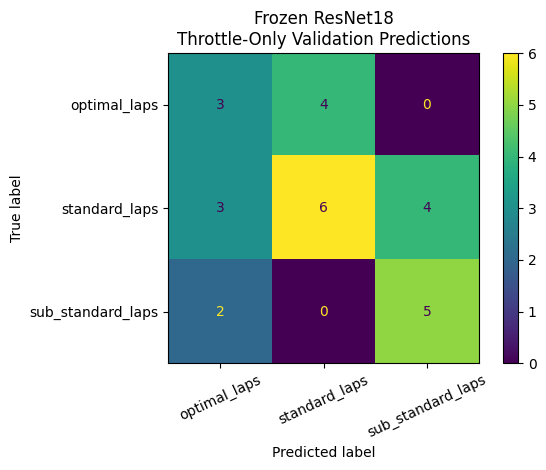

In [95]:
ConfusionMatrixDisplay.from_predictions(
    y_throttle_validation,
    throttle_validation_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    values_format="d",
)

plt.title(
    "Frozen ResNet18\n"
    "Throttle-Only Validation Predictions"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

Save the probabilities:

In [96]:
throttle_validation_probability_df = (
    best_throttle_validation_results[[
        "global_lap_num",
        "session",
        "session_lap_num",
        "class_name",
        "class_index",
        "throttle_predicted_class_index",
        "throttle_probability_optimal",
        "throttle_probability_standard",
        "throttle_probability_sub_standard",
    ]]
    .copy()
)

last_block_throttle_probability_path = (
    manifest_dir
    / "last-block-cnn-throttle-validation-probabilities.csv"
)

throttle_validation_probability_df.to_csv(
    last_block_throttle_probability_path,
    index=False,
)

print(
    "Saved last-block CNN probabilities:",
    last_block_throttle_probability_path,
)

Saved last-block CNN probabilities: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\last-block-cnn-throttle-validation-probabilities.csv


## 6. Delta-only logistic regression


In [28]:
delta_feature_columns = [
    "delta_1_seconds",
    "delta_2_seconds",
]

delta_available_mask = (
    lap_manifest_with_split[
        "delta_1_seconds"
    ].notna()
    & lap_manifest_with_split[
        "delta_2_seconds"
    ].notna()
)

delta_laps = (
    lap_manifest_with_split[
        delta_available_mask
    ]
    .copy()
    .reset_index(drop=True)
)

delta_train_df = (
    delta_laps[
        delta_laps["split"] == "train"
    ]
    .copy()
    .reset_index(drop=True)
)

delta_validation_df = (
    delta_laps[
        delta_laps["split"] == "validation"
    ]
    .copy()
    .reset_index(drop=True)
)

delta_test_df = (
    delta_laps[
        delta_laps["split"] == "test"
    ]
    .copy()
    .reset_index(drop=True)
)

X_delta_train = delta_train_df[
    delta_feature_columns
].to_numpy()

y_delta_train = delta_train_df[
    "class_index"
].to_numpy()

X_delta_validation = delta_validation_df[
    delta_feature_columns
].to_numpy()

y_delta_validation = delta_validation_df[
    "class_index"
].to_numpy()

print("Delta training laps:", len(delta_train_df))
print(
    "Delta validation laps:",
    len(delta_validation_df),
)
print(
    "Delta test laps reserved:",
    len(delta_test_df),
)


Delta training laps: 111
Delta validation laps: 27
Delta test laps reserved: 31


In [29]:
training_class_counts = (
    delta_train_df["class_index"]
    .value_counts()
)

majority_class_index = int(
    training_class_counts.idxmax()
)

majority_validation_predictions = np.full(
    len(y_delta_validation),
    majority_class_index,
)

majority_validation_accuracy = accuracy_score(
    y_delta_validation,
    majority_validation_predictions,
)

majority_validation_balanced_accuracy = (
    balanced_accuracy_score(
        y_delta_validation,
        majority_validation_predictions,
    )
)

delta_model = Pipeline([
    ("scaler", StandardScaler()),
    (
        "classifier",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=seed,
        ),
    ),
])

delta_model.fit(
    X_delta_train,
    y_delta_train,
)

delta_validation_predictions = (
    delta_model.predict(
        X_delta_validation
    )
)

delta_validation_probabilities = (
    delta_model.predict_proba(
        X_delta_validation
    )
)

delta_validation_accuracy = accuracy_score(
    y_delta_validation,
    delta_validation_predictions,
)

delta_validation_balanced_accuracy = (
    balanced_accuracy_score(
        y_delta_validation,
        delta_validation_predictions,
    )
)

print(
    "Majority baseline accuracy:",
    f"{majority_validation_accuracy:.4f}",
)

print(
    "Majority baseline balanced accuracy:",
    f"{majority_validation_balanced_accuracy:.4f}",
)

print(
    "Delta validation accuracy:",
    f"{delta_validation_accuracy:.4f}",
)

print(
    "Delta validation balanced accuracy:",
    f"{delta_validation_balanced_accuracy:.4f}",
)


Majority baseline accuracy: 0.4815
Majority baseline balanced accuracy: 0.3333
Delta validation accuracy: 0.5926
Delta validation balanced accuracy: 0.6300


                   precision    recall  f1-score   support

     optimal_laps     0.3846    0.7143    0.5000         7
    standard_laps     0.6667    0.4615    0.5455        13
sub_standard_laps     1.0000    0.7143    0.8333         7

         accuracy                         0.5926        27
        macro avg     0.6838    0.6300    0.6263        27
     weighted avg     0.6800    0.5926    0.6083        27



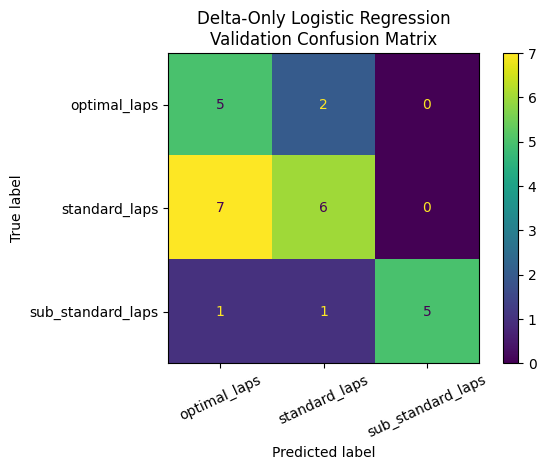

In [30]:
print(
    classification_report(
        y_delta_validation,
        delta_validation_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_delta_validation,
    delta_validation_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    values_format="d",
)

plt.title(
    "Delta-Only Logistic Regression\n"
    "Validation Confusion Matrix"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


In [31]:
delta_model_class_order = (
    delta_model.named_steps[
        "classifier"
    ].classes_
)

assert np.array_equal(
    delta_model_class_order,
    np.arange(num_classes),
)

delta_validation_probability_df = pd.DataFrame({
    "global_lap_num":
        delta_validation_df[
            "global_lap_num"
        ].to_numpy(),

    "true_class_index":
        y_delta_validation,

    "delta_predicted_class_index":
        delta_validation_predictions,

    "delta_probability_optimal":
        delta_validation_probabilities[:, 0],

    "delta_probability_standard":
        delta_validation_probabilities[:, 1],

    "delta_probability_sub_standard":
        delta_validation_probabilities[:, 2],
})

delta_validation_probability_path = (
    manifest_dir
    / "delta-validation-probabilities.csv"
)

delta_validation_probability_df.to_csv(
    delta_validation_probability_path,
    index=False,
)

display(
    delta_validation_probability_df.head()
)

print(
    "Saved delta validation probabilities:",
    delta_validation_probability_path,
)


,global_lap_num,true_class_index,delta_predicted_class_index,delta_probability_optimal,delta_probability_standard,delta_probability_sub_standard
0,99,1,0,0.556025,0.401710,0.042265
1,100,2,2,0.021701,0.147629,0.830670
2,102,1,1,0.179959,0.455430,0.364611
3,104,2,0,0.536363,0.419208,0.044428
4,163,1,0,0.558351,0.412102,0.029547


Saved delta validation probabilities: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\delta-validation-probabilities.csv


## 7. CNN validation outputs and lap-level aggregation


In [82]:
validation_logits_batches = []
validation_probability_batches = []
validation_prediction_batches = []
validation_label_batches = []

model.eval()

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        logits = model(images)

        probabilities = torch.softmax(
            logits,
            dim=1,
        )

        predictions = logits.argmax(dim=1)

        validation_logits_batches.append(
            logits.cpu().numpy()
        )

        validation_probability_batches.append(
            probabilities.cpu().numpy()
        )

        validation_prediction_batches.append(
            predictions.cpu().numpy()
        )

        validation_label_batches.append(
            labels.numpy()
        )

validation_image_logits = np.concatenate(
    validation_logits_batches,
    axis=0,
)

validation_image_probabilities = np.concatenate(
    validation_probability_batches,
    axis=0,
)

validation_image_predictions = np.concatenate(
    validation_prediction_batches,
    axis=0,
)

validation_image_labels = np.concatenate(
    validation_label_batches,
    axis=0,
)

assert validation_image_logits.shape == (108, 3)

assert np.array_equal(
    validation_image_df[
        "class_index"
    ].to_numpy(),
    validation_image_labels,
)

print(
    "Validation logits shape:",
    validation_image_logits.shape,
)

print(
    "Validation probabilities shape:",
    validation_image_probabilities.shape,
)


Validation logits shape: (108, 3)
Validation probabilities shape: (108, 3)


In [33]:
cnn_aggregation_image_df = (
    validation_image_df.copy()
)

for class_index, class_label in enumerate([
    "optimal",
    "standard",
    "sub_standard",
]):
    cnn_aggregation_image_df[
        f"logit_{class_label}"
    ] = validation_image_logits[
        :,
        class_index,
    ]

    cnn_aggregation_image_df[
        f"probability_{class_label}"
    ] = validation_image_probabilities[
        :,
        class_index,
    ]

cnn_aggregation_image_df[
    "image_predicted_class_index"
] = validation_image_predictions

cnn_aggregation_image_df[
    "image_predicted_class_name"
] = [
    class_names[class_index]
    for class_index
    in validation_image_predictions
]

display(
    cnn_aggregation_image_df[[
        "global_lap_num",
        "signal_type",
        "hit_number",
        "class_name",
        "image_predicted_class_name",
        "probability_optimal",
        "probability_standard",
        "probability_sub_standard",
    ]].head(12)
)


,global_lap_num,signal_type,hit_number,class_name,image_predicted_class_name,probability_optimal,probability_standard,probability_sub_standard
0,99,brake,1,standard_laps,optimal_laps,0.721920,0.014120,0.263960
1,99,brake,2,standard_laps,standard_laps,0.348004,0.554309,0.097686
2,99,throttle,1,standard_laps,standard_laps,0.456348,0.530465,0.013188
3,99,throttle,2,standard_laps,sub_standard_laps,0.008896,0.192917,0.798186
4,100,brake,1,sub_standard_laps,sub_standard_laps,0.394816,0.109289,0.495895
5,100,brake,2,sub_standard_laps,standard_laps,0.001330,0.993419,0.005251
6,100,throttle,1,sub_standard_laps,sub_standard_laps,0.045638,0.087146,0.867216
7,100,throttle,2,sub_standard_laps,standard_laps,0.001918,0.985090,0.012992
8,102,brake,1,standard_laps,standard_laps,0.096003,0.895195,0.008802
9,102,brake,2,standard_laps,standard_laps,0.000318,0.992991,0.006692


In [34]:
probability_columns = [
    "probability_optimal",
    "probability_standard",
    "probability_sub_standard",
]

logit_columns = [
    "logit_optimal",
    "logit_standard",
    "logit_sub_standard",
]


def numpy_softmax(values):
    shifted_values = (
        values
        - values.max(
            axis=1,
            keepdims=True,
        )
    )

    exponentials = np.exp(
        shifted_values
    )

    return (
        exponentials
        / exponentials.sum(
            axis=1,
            keepdims=True,
        )
    )


def majority_vote_with_probability_tiebreak(
    image_predictions,
    image_probabilities,
):
    vote_counts = np.bincount(
        image_predictions,
        minlength=num_classes,
    )

    tied_classes = np.flatnonzero(
        vote_counts == vote_counts.max()
    )

    if len(tied_classes) == 1:
        return int(tied_classes[0])

    mean_probabilities = (
        image_probabilities.mean(axis=0)
    )

    return int(
        tied_classes[
            mean_probabilities[
                tied_classes
            ].argmax()
        ]
    )


In [36]:
aggregation_records = []

for global_lap_num, lap_images in (
    cnn_aggregation_image_df
    .groupby("global_lap_num")
):
    lap_images = (
        lap_images
        .sort_values([
            "signal_type",
            "hit_number",
        ])
        .reset_index(drop=True)
    )

    if len(lap_images) != 4:
        raise ValueError(
            f"Lap {global_lap_num} has "
            f"{len(lap_images)} images."
        )

    first_row = lap_images.iloc[0]

    all_probabilities = (
        lap_images[
            probability_columns
        ].to_numpy()
    )

    all_logits = (
        lap_images[
            logit_columns
        ].to_numpy()
    )

    all_image_predictions = (
        lap_images[
            "image_predicted_class_index"
        ].to_numpy()
    )

    brake_images = lap_images[
        lap_images["signal_type"]
        == "brake"
    ]

    throttle_images = lap_images[
        lap_images["signal_type"]
        == "throttle"
    ]

    mean_softmax_probabilities = (
        all_probabilities.mean(axis=0)
    )

    mean_logit_probabilities = (
        numpy_softmax(
            all_logits.mean(
                axis=0,
                keepdims=True,
            )
        )[0]
    )

    brake_probabilities = (
        brake_images[
            probability_columns
        ].to_numpy().mean(axis=0)
    )

    throttle_probabilities = (
        throttle_images[
            probability_columns
        ].to_numpy().mean(axis=0)
    )

    aggregation_records.append({
        "global_lap_num":
            int(global_lap_num),

        "session":
            int(first_row["session"]),

        "session_lap_num":
            int(first_row["session_lap_num"]),

        "class_name":
            first_row["class_name"],

        "class_index":
            int(first_row["class_index"]),

        "mean_softmax_prediction":
            int(mean_softmax_probabilities.argmax()),

        "mean_logits_prediction":
            int(mean_logit_probabilities.argmax()),

        "majority_vote_prediction":
            majority_vote_with_probability_tiebreak(
                all_image_predictions,
                all_probabilities,
            ),

        "brake_only_prediction":
            int(brake_probabilities.argmax()),

        "throttle_only_prediction":
            int(throttle_probabilities.argmax()),

        "mean_softmax_probability_optimal":
            mean_softmax_probabilities[0],

        "mean_softmax_probability_standard":
            mean_softmax_probabilities[1],

        "mean_softmax_probability_sub_standard":
            mean_softmax_probabilities[2],

        "mean_logits_probability_optimal":
            mean_logit_probabilities[0],

        "mean_logits_probability_standard":
            mean_logit_probabilities[1],

        "mean_logits_probability_sub_standard":
            mean_logit_probabilities[2],

        "brake_probability_optimal":
            brake_probabilities[0],

        "brake_probability_standard":
            brake_probabilities[1],

        "brake_probability_sub_standard":
            brake_probabilities[2],

        "throttle_probability_optimal":
            throttle_probabilities[0],

        "throttle_probability_standard":
            throttle_probabilities[1],

        "throttle_probability_sub_standard":
            throttle_probabilities[2],
    })

cnn_aggregation_results = (
    pd.DataFrame(aggregation_records)
    .sort_values("global_lap_num")
    .reset_index(drop=True)
)

# assert len(cnn_aggregation_results) == 18

display(
    cnn_aggregation_results.head()
)


,global_lap_num,session,session_lap_num,class_name,class_index,mean_softmax_prediction,mean_logits_prediction,majority_vote_prediction,brake_only_prediction,throttle_only_prediction,...,mean_softmax_probability_sub_standard,mean_logits_probability_optimal,mean_logits_probability_standard,mean_logits_probability_sub_standard,brake_probability_optimal,brake_probability_standard,brake_probability_sub_standard,throttle_probability_optimal,throttle_probability_standard,throttle_probability_sub_standard
0,99,11,1,standard_laps,1,0,0,1,0,2,...,0.293255,0.375996,0.353951,0.270052,0.534962,0.284215,0.180823,0.232622,0.361691,0.405687
1,100,11,2,sub_standard_laps,2,1,1,1,1,1,...,0.345339,0.036699,0.778824,0.184478,0.198073,0.551354,0.250573,0.023778,0.536118,0.440104
2,102,11,4,standard_laps,1,1,1,1,1,1,...,0.145942,0.019768,0.927518,0.052714,0.048160,0.944093,0.007747,0.050829,0.665034,0.284137
3,104,11,6,sub_standard_laps,2,1,1,1,1,2,...,0.248625,0.088240,0.701637,0.210123,0.072424,0.816569,0.111007,0.328714,0.285044,0.386243
4,163,18,2,standard_laps,1,0,0,0,0,0,...,0.141570,0.435506,0.398901,0.165593,0.404858,0.333109,0.262033,0.502803,0.476089,0.021108


In [38]:
y_cnn_validation = (
    cnn_aggregation_results[
        "class_index"
    ].to_numpy()
)

aggregation_methods = {
    "Mean softmax — all four images":
        "mean_softmax_prediction",

    "Mean logits, then softmax":
        "mean_logits_prediction",

    "Majority vote":
        "majority_vote_prediction",

    "Brake images only":
        "brake_only_prediction",

    "Throttle images only":
        "throttle_only_prediction",
}

aggregation_metric_records = []

for method_name, prediction_column in (
    aggregation_methods.items()
):
    predictions = (
        cnn_aggregation_results[
            prediction_column
        ].to_numpy()
    )

    aggregation_metric_records.append({
        "aggregation_method":
            method_name,

        "accuracy":
            accuracy_score(
                y_cnn_validation,
                predictions,
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_cnn_validation,
                predictions,
            ),

        "correct_laps":
            int(
                (
                    y_cnn_validation
                    == predictions
                ).sum()
            ),

        "total_laps":
            len(y_cnn_validation),
    })

cnn_aggregation_comparison = (
    pd.DataFrame(
        aggregation_metric_records
    )
    .sort_values(
        [
            "balanced_accuracy",
            "accuracy",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    cnn_aggregation_comparison
)


,aggregation_method,accuracy,balanced_accuracy,correct_laps,total_laps
0,Throttle images only,0.518519,0.512821,14,27
1,"Mean logits, then softmax",0.444444,0.351648,12,27
2,Brake images only,0.407407,0.347985,11,27
3,Majority vote,0.370370,0.278388,10,27
4,Mean softmax — all four images,0.333333,0.252747,9,27


Best standalone CNN aggregation: Throttle images only
                   precision    recall  f1-score   support

     optimal_laps     0.3750    0.4286    0.4000         7
    standard_laps     0.5385    0.5385    0.5385        13
sub_standard_laps     0.6667    0.5714    0.6154         7

         accuracy                         0.5185        27
        macro avg     0.5267    0.5128    0.5179        27
     weighted avg     0.5293    0.5185    0.5225        27



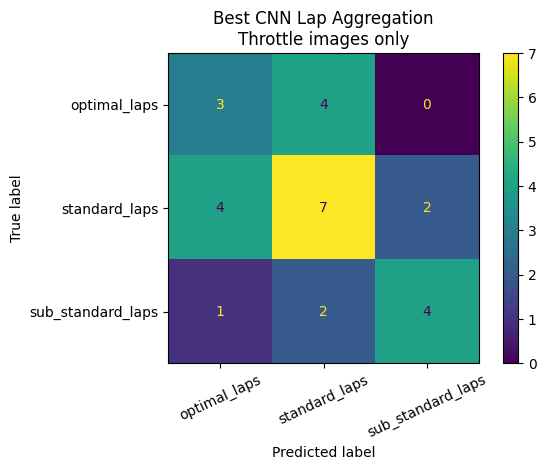

In [39]:
best_aggregation_method = (
    cnn_aggregation_comparison
    .iloc[0]["aggregation_method"]
)

best_prediction_column = (
    aggregation_methods[
        best_aggregation_method
    ]
)

best_aggregation_predictions = (
    cnn_aggregation_results[
        best_prediction_column
    ].to_numpy()
)

print(
    "Best standalone CNN aggregation:",
    best_aggregation_method,
)

print(
    classification_report(
        y_cnn_validation,
        best_aggregation_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

ConfusionMatrixDisplay.from_predictions(
    y_cnn_validation,
    best_aggregation_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    values_format="d",
)

plt.title(
    "Best CNN Lap Aggregation\n"
    f"{best_aggregation_method}"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


In [40]:
cnn_aggregation_results_path = (
    manifest_dir
    / "cnn-validation-aggregation-results.csv"
)

cnn_aggregation_comparison_path = (
    manifest_dir
    / "cnn-validation-aggregation-comparison.csv"
)

cnn_aggregation_results.to_csv(
    cnn_aggregation_results_path,
    index=False,
)

cnn_aggregation_comparison.to_csv(
    cnn_aggregation_comparison_path,
    index=False,
)

print(
    "Saved CNN aggregation results:",
    cnn_aggregation_results_path,
)


Saved CNN aggregation results: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\cnn-validation-aggregation-results.csv


## 8. CNN and delta probability fusion


In [97]:
fusion_validation_df = (
    throttle_validation_probability_df
    .merge(
        delta_validation_probability_df,
        on="global_lap_num",
        how="inner",
        validate="one_to_one",
    )
)

assert len(fusion_validation_df) == len(
    delta_validation_df
)

assert (
    fusion_validation_df[
        "class_index"
    ]
    == fusion_validation_df[
        "true_class_index"
    ]
).all()

cnn_validation_probabilities = (
    fusion_validation_df[[
        "throttle_probability_optimal",
        "throttle_probability_standard",
        "throttle_probability_sub_standard",
    ]]
    .to_numpy()
)

delta_validation_probabilities = (
    fusion_validation_df[[
        "delta_probability_optimal",
        "delta_probability_standard",
        "delta_probability_sub_standard",
    ]]
    .to_numpy()
)

fusion_true_labels = (
    fusion_validation_df[
        "class_index"
    ].to_numpy()
)

print(
    "Validation laps available for fusion:",
    len(fusion_validation_df),
)

Validation laps available for fusion: 27


In [98]:
fusion_weight_records = []

for cnn_weight in np.linspace(
    0.0,
    1.0,
    101,
):
    delta_weight = 1.0 - cnn_weight

    combined_probabilities = (
        cnn_weight
        * cnn_validation_probabilities
        + delta_weight
        * delta_validation_probabilities
    )

    combined_predictions = (
        combined_probabilities.argmax(
            axis=1
        )
    )

    fusion_weight_records.append({
        "cnn_weight": cnn_weight,
        "delta_weight": delta_weight,
        "accuracy": accuracy_score(
            fusion_true_labels,
            combined_predictions,
        ),
        "balanced_accuracy":
            balanced_accuracy_score(
                fusion_true_labels,
                combined_predictions,
            ),
    })

fusion_weight_results = pd.DataFrame(
    fusion_weight_records
)

best_fusion_row = (
    fusion_weight_results
    .sort_values(
        [
            "balanced_accuracy",
            "accuracy",
            "cnn_weight",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .iloc[0]
)

best_cnn_weight = float(
    best_fusion_row["cnn_weight"]
)

best_delta_weight = float(
    best_fusion_row["delta_weight"]
)

best_fusion_probabilities = (
    best_cnn_weight
    * cnn_validation_probabilities
    + best_delta_weight
    * delta_validation_probabilities
)

best_fusion_predictions = (
    best_fusion_probabilities.argmax(
        axis=1
    )
)

print("Best CNN weight:", best_cnn_weight)
print("Best delta weight:", best_delta_weight)

print(
    "Fusion validation accuracy:",
    f"{accuracy_score(fusion_true_labels, best_fusion_predictions):.4f}",
)

print(
    "Fusion validation balanced accuracy:",
    f"{balanced_accuracy_score(fusion_true_labels, best_fusion_predictions):.4f}",
)

Best CNN weight: 0.38
Best delta weight: 0.62
Fusion validation accuracy: 0.6667
Fusion validation balanced accuracy: 0.6813


                   precision    recall  f1-score   support

     optimal_laps     0.4167    0.7143    0.5263         7
    standard_laps     0.8000    0.6154    0.6957        13
sub_standard_laps     1.0000    0.7143    0.8333         7

         accuracy                         0.6667        27
        macro avg     0.7389    0.6813    0.6851        27
     weighted avg     0.7525    0.6667    0.6874        27



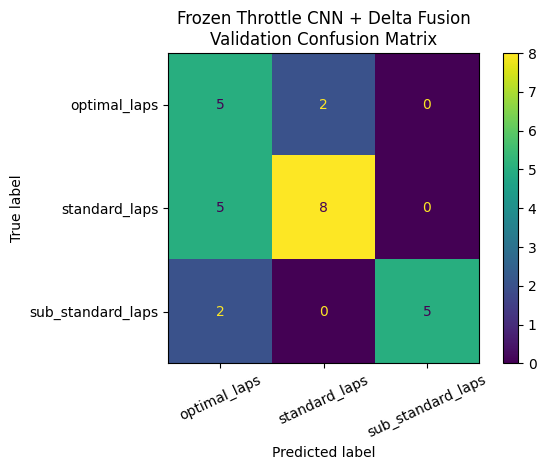

In [99]:
print(
    classification_report(
        fusion_true_labels,
        best_fusion_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

ConfusionMatrixDisplay.from_predictions(
    fusion_true_labels,
    best_fusion_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    values_format="d",
)

plt.title(
    "Frozen Throttle CNN + Delta Fusion\n"
    "Validation Confusion Matrix"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [100]:
last_block_fusion_comparison = pd.DataFrame({
    "model": [
        "Majority baseline",
        "Last-block throttle-only CNN",
        "Delta logistic regression",
        "Last-block throttle CNN + delta fusion",
    ],
    "accuracy": [
        majority_validation_accuracy,
        last_block_throttle_accuracy,
        delta_validation_accuracy,
        accuracy_score(
            fusion_true_labels,
            best_fusion_predictions,
        ),
    ],
    "balanced_accuracy": [
        majority_validation_balanced_accuracy,
        last_block_throttle_balanced_accuracy,
        delta_validation_balanced_accuracy,
        balanced_accuracy_score(
            fusion_true_labels,
            best_fusion_predictions,
        ),
    ],
})

display(
    last_block_fusion_comparison
)

,model,accuracy,balanced_accuracy
0,Majority baseline,0.481481,0.333333
1,Last-block throttle-only CNN,0.518519,0.534799
2,Delta logistic regression,0.592593,0.630037
3,Last-block throttle CNN + delta fusion,0.666667,0.681319


In [101]:
fusion_validation_results = (
    fusion_validation_df[[
        "global_lap_num",
        "session",
        "session_lap_num",
        "class_name",
        "class_index",
    ]]
    .copy()
)

fusion_validation_results[
    "fusion_predicted_class_index"
] = best_fusion_predictions

fusion_validation_results[
    "fusion_probability_optimal"
] = best_fusion_probabilities[:, 0]

fusion_validation_results[
    "fusion_probability_standard"
] = best_fusion_probabilities[:, 1]

fusion_validation_results[
    "fusion_probability_sub_standard"
] = best_fusion_probabilities[:, 2]

fusion_validation_results[
    "cnn_weight"
] = best_cnn_weight

fusion_validation_results[
    "delta_weight"
] = best_delta_weight

fusion_results_path = (
    manifest_dir
    / "fusion-validation-results.csv"
)

fusion_validation_results.to_csv(
    fusion_results_path,
    index=False,
)

print(
    "Saved fusion validation results:",
    fusion_results_path,
)


Saved fusion validation results: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\fusion-validation-results.csv


## 10 Fusion

### 10.1 Geometric probability fusion

In [102]:
geometric_fusion_records = []

epsilon = 1e-8

for cnn_weight in np.linspace(
    0.0,
    1.0,
    101,
):
    delta_weight = 1.0 - cnn_weight

    combined_log_probabilities = (
        cnn_weight
        * np.log(
            cnn_validation_probabilities
            + epsilon
        )
        + delta_weight
        * np.log(
            delta_validation_probabilities
            + epsilon
        )
    )

    # Convert the log scores back into normalised
    # probabilities.
    combined_log_probabilities = (
        combined_log_probabilities
        - combined_log_probabilities.max(
            axis=1,
            keepdims=True,
        )
    )

    combined_probabilities = np.exp(
        combined_log_probabilities
    )

    combined_probabilities = (
        combined_probabilities
        / combined_probabilities.sum(
            axis=1,
            keepdims=True,
        )
    )

    combined_predictions = (
        combined_probabilities.argmax(
            axis=1
        )
    )

    geometric_fusion_records.append({
        "cnn_weight": cnn_weight,
        "delta_weight": delta_weight,
        "accuracy": accuracy_score(
            fusion_true_labels,
            combined_predictions,
        ),
        "balanced_accuracy":
            balanced_accuracy_score(
                fusion_true_labels,
                combined_predictions,
            ),
    })


geometric_fusion_results = pd.DataFrame(
    geometric_fusion_records
)

best_geometric_row = (
    geometric_fusion_results
    .sort_values(
        [
            "balanced_accuracy",
            "accuracy",
            "cnn_weight",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .iloc[0]
)

best_geometric_cnn_weight = float(
    best_geometric_row["cnn_weight"]
)

best_geometric_delta_weight = float(
    best_geometric_row["delta_weight"]
)

print(
    "Best geometric CNN weight:",
    best_geometric_cnn_weight,
)

print(
    "Best geometric delta weight:",
    best_geometric_delta_weight,
)

print(
    "Geometric fusion accuracy:",
    f"{best_geometric_row['accuracy']:.4f}",
)

print(
    "Geometric fusion balanced accuracy:",
    f"{best_geometric_row['balanced_accuracy']:.4f}",
)

Best geometric CNN weight: 0.37
Best geometric delta weight: 0.63
Geometric fusion accuracy: 0.7037
Geometric fusion balanced accuracy: 0.7070


In [103]:
best_geometric_log_probabilities = (
    best_geometric_cnn_weight
    * np.log(
        cnn_validation_probabilities
        + epsilon
    )
    + best_geometric_delta_weight
    * np.log(
        delta_validation_probabilities
        + epsilon
    )
)

best_geometric_predictions = (
    best_geometric_log_probabilities.argmax(
        axis=1
    )
)

print(
    classification_report(
        fusion_true_labels,
        best_geometric_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

                   precision    recall  f1-score   support

     optimal_laps     0.4545    0.7143    0.5556         7
    standard_laps     0.8182    0.6923    0.7500        13
sub_standard_laps     1.0000    0.7143    0.8333         7

         accuracy                         0.7037        27
        macro avg     0.7576    0.7070    0.7130        27
     weighted avg     0.7710    0.7037    0.7212        27



### 10.2 Confidence-gated fusion

In [104]:
cnn_predictions = (
    cnn_validation_probabilities.argmax(
        axis=1
    )
)

delta_predictions = (
    delta_validation_probabilities.argmax(
        axis=1
    )
)

cnn_confidences = (
    cnn_validation_probabilities.max(
        axis=1
    )
)

delta_confidences = (
    delta_validation_probabilities.max(
        axis=1
    )
)

gating_records = []

for minimum_cnn_confidence in np.linspace(
    0.35,
    0.90,
    23,
):
    for required_confidence_advantage in np.linspace(
        0.0,
        0.30,
        13,
    ):
        use_cnn = (
            (
                cnn_confidences
                >= minimum_cnn_confidence
            )
            & (
                cnn_confidences
                >= (
                    delta_confidences
                    + required_confidence_advantage
                )
            )
        )

        gated_predictions = np.where(
            use_cnn,
            cnn_predictions,
            delta_predictions,
        )

        gating_records.append({
            "minimum_cnn_confidence":
                minimum_cnn_confidence,

            "required_confidence_advantage":
                required_confidence_advantage,

            "cnn_overrides":
                int(use_cnn.sum()),

            "accuracy":
                accuracy_score(
                    fusion_true_labels,
                    gated_predictions,
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    fusion_true_labels,
                    gated_predictions,
                ),
        })


gating_results = pd.DataFrame(
    gating_records
)

best_gating_row = (
    gating_results
    .sort_values(
        [
            "balanced_accuracy",
            "accuracy",
            "cnn_overrides",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .iloc[0]
)

display(
    best_gating_row.to_frame().T
)

,minimum_cnn_confidence,required_confidence_advantage,cnn_overrides,accuracy,balanced_accuracy
2,0.35,0.05,4.0,0.592593,0.652015


In [105]:
best_minimum_cnn_confidence = float(
    best_gating_row[
        "minimum_cnn_confidence"
    ]
)

best_required_advantage = float(
    best_gating_row[
        "required_confidence_advantage"
    ]
)

best_use_cnn = (
    (
        cnn_confidences
        >= best_minimum_cnn_confidence
    )
    & (
        cnn_confidences
        >= (
            delta_confidences
            + best_required_advantage
        )
    )
)

best_gated_predictions = np.where(
    best_use_cnn,
    cnn_predictions,
    delta_predictions,
)

print(
    "CNN overrides:",
    int(best_use_cnn.sum()),
    "of",
    len(best_use_cnn),
)

print(
    "Gated fusion accuracy:",
    f"{accuracy_score(fusion_true_labels, best_gated_predictions):.4f}",
)

print(
    "Gated fusion balanced accuracy:",
    f"{balanced_accuracy_score(fusion_true_labels, best_gated_predictions):.4f}",
)

CNN overrides: 4 of 27
Gated fusion accuracy: 0.5926
Gated fusion balanced accuracy: 0.6520


### 10.3 Compare all three fusion approaches

In [106]:
fusion_method_comparison = pd.DataFrame({
    "fusion_method": [
        "Delta only",
        "Arithmetic probability blend",
        "Geometric probability blend",
        "Confidence-gated fusion",
    ],
    "accuracy": [
        delta_validation_accuracy,

        accuracy_score(
            fusion_true_labels,
            best_fusion_predictions,
        ),

        accuracy_score(
            fusion_true_labels,
            best_geometric_predictions,
        ),

        accuracy_score(
            fusion_true_labels,
            best_gated_predictions,
        ),
    ],
    "balanced_accuracy": [
        delta_validation_balanced_accuracy,

        balanced_accuracy_score(
            fusion_true_labels,
            best_fusion_predictions,
        ),

        balanced_accuracy_score(
            fusion_true_labels,
            best_geometric_predictions,
        ),

        balanced_accuracy_score(
            fusion_true_labels,
            best_gated_predictions,
        ),
    ],
})

display(
    fusion_method_comparison.sort_values(
        [
            "balanced_accuracy",
            "accuracy",
        ],
        ascending=False,
    )
)

,fusion_method,accuracy,balanced_accuracy
2,Geometric probability blend,0.703704,0.706960
1,Arithmetic probability blend,0.666667,0.681319
3,Confidence-gated fusion,0.592593,0.652015
0,Delta only,0.592593,0.630037


Geometric fusion produced the strongest validation result, correctly classifying 19 of 27 laps, although its balanced-accuracy advantage over the previous best fusion was marginal.

## 11 Compare geometric fusion across all saved CNNs

In [107]:
cnn_checkpoint_paths = {
    "Fully fine-tuned": (
        project_root
        / "Code"
        / "best_resnet18.pth"
    ),

    "Fully frozen": (
        project_root
        / "Code"
        / "best_resnet18_frozen_throttle.pth"
    ),

    "Entire layer4 trainable": (
        project_root
        / "Code"
        / "best_resnet18_partial_throttle.pth"
    ),

    "Last block trainable": (
        project_root
        / "Code"
        / "best_resnet18_last_block_throttle.pth"
    ),
}


for model_name, checkpoint_path in (
    cnn_checkpoint_paths.items()
):
    if not checkpoint_path.exists():
        raise FileNotFoundError(
            f"{model_name} checkpoint was not found:\n"
            f"{checkpoint_path}"
        )

    print(
        f"{model_name}:",
        checkpoint_path,
    )

Fully fine-tuned: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Code\best_resnet18.pth
Fully frozen: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Code\best_resnet18_frozen_throttle.pth
Entire layer4 trainable: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Code\best_resnet18_partial_throttle.pth
Last block trainable: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Code\best_resnet18_last_block_throttle.pth


In [108]:
def load_resnet18_checkpoint(
    checkpoint_path,
):
    """
    Create the common ResNet18 architecture and load
    one saved checkpoint for evaluation.
    """
    evaluation_model = models.resnet18(
        weights=None,
    )

    evaluation_model.fc = nn.Linear(
        evaluation_model.fc.in_features,
        num_classes,
    )

    state_dict = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=True,
    )

    evaluation_model.load_state_dict(
        state_dict
    )

    evaluation_model = (
        evaluation_model.to(device)
    )

    evaluation_model.eval()

    return evaluation_model

In [109]:
def geometric_probability_fusion(
    cnn_probabilities,
    delta_probabilities,
    cnn_weight,
    epsilon=1e-8,
):
    """
    Weighted geometric fusion:

    combined[c] is proportional to
    CNN[c] ** cnn_weight
    multiplied by
    Delta[c] ** (1 - cnn_weight)
    """
    delta_weight = 1.0 - cnn_weight

    combined_log_probabilities = (
        cnn_weight
        * np.log(
            cnn_probabilities
            + epsilon
        )
        + delta_weight
        * np.log(
            delta_probabilities
            + epsilon
        )
    )

    # Stabilise before exponentiating.
    combined_log_probabilities = (
        combined_log_probabilities
        - combined_log_probabilities.max(
            axis=1,
            keepdims=True,
        )
    )

    combined_probabilities = np.exp(
        combined_log_probabilities
    )

    combined_probabilities = (
        combined_probabilities
        / combined_probabilities.sum(
            axis=1,
            keepdims=True,
        )
    )

    return combined_probabilities

### 11.1 Evaluate:

In [110]:
checkpoint_comparison_records = []

checkpoint_validation_results = {}
checkpoint_weight_search_results = {}

for model_name, checkpoint_path in (
    cnn_checkpoint_paths.items()
):
    print("\n" + "=" * 75)
    print(model_name)
    print("=" * 75)

    evaluation_model = (
        load_resnet18_checkpoint(
            checkpoint_path
        )
    )

    # Generate image-level validation probabilities.
    checkpoint_image_results = (
        collect_image_probabilities(
            evaluation_model,
            val_loader,
            validation_image_df,
        )
    )

    # Average the two throttle-image probability
    # vectors belonging to each lap.
    checkpoint_throttle_results = (
        aggregate_throttle_probabilities(
            checkpoint_image_results
        )
    )

    assert (
        len(checkpoint_throttle_results)
        == len(validation_lap_df)
    )

    # Merge with the delta model probabilities.
    checkpoint_fusion_df = (
        checkpoint_throttle_results
        .merge(
            delta_validation_probability_df,
            on="global_lap_num",
            how="inner",
            validate="one_to_one",
        )
        .sort_values("global_lap_num")
        .reset_index(drop=True)
    )

    assert len(checkpoint_fusion_df) == len(
        delta_validation_df
    )

    assert (
        checkpoint_fusion_df[
            "class_index"
        ].to_numpy()
        == checkpoint_fusion_df[
            "true_class_index"
        ].to_numpy()
    ).all()

    true_labels = (
        checkpoint_fusion_df[
            "class_index"
        ].to_numpy()
    )

    cnn_probabilities = (
        checkpoint_fusion_df[[
            "throttle_probability_optimal",
            "throttle_probability_standard",
            "throttle_probability_sub_standard",
        ]]
        .to_numpy()
    )

    delta_probabilities = (
        checkpoint_fusion_df[[
            "delta_probability_optimal",
            "delta_probability_standard",
            "delta_probability_sub_standard",
        ]]
        .to_numpy()
    )

    # Standalone throttle CNN performance.
    cnn_predictions = (
        cnn_probabilities.argmax(axis=1)
    )

    cnn_accuracy = accuracy_score(
        true_labels,
        cnn_predictions,
    )

    cnn_balanced_accuracy = (
        balanced_accuracy_score(
            true_labels,
            cnn_predictions,
        )
    )

    # Search the geometric-fusion weight.
    weight_records = []

    for cnn_weight in np.linspace(
        0.0,
        1.0,
        101,
    ):
        combined_probabilities = (
            geometric_probability_fusion(
                cnn_probabilities=(
                    cnn_probabilities
                ),
                delta_probabilities=(
                    delta_probabilities
                ),
                cnn_weight=cnn_weight,
            )
        )

        combined_predictions = (
            combined_probabilities.argmax(
                axis=1
            )
        )

        weight_records.append({
            "cnn_model":
                model_name,

            "cnn_weight":
                cnn_weight,

            "delta_weight":
                1.0 - cnn_weight,

            "accuracy":
                accuracy_score(
                    true_labels,
                    combined_predictions,
                ),

            "balanced_accuracy":
                balanced_accuracy_score(
                    true_labels,
                    combined_predictions,
                ),
        })

    weight_results_df = pd.DataFrame(
        weight_records
    )

    # Primary selection: balanced accuracy.
    # First tie-break: ordinary accuracy.
    # Second tie-break: smaller CNN weight.
    best_weight_row = (
        weight_results_df
        .sort_values(
            [
                "balanced_accuracy",
                "accuracy",
                "cnn_weight",
            ],
            ascending=[
                False,
                False,
                True,
            ],
        )
        .iloc[0]
    )

    best_cnn_weight = float(
        best_weight_row["cnn_weight"]
    )

    best_delta_weight = float(
        best_weight_row["delta_weight"]
    )

    best_combined_probabilities = (
        geometric_probability_fusion(
            cnn_probabilities=(
                cnn_probabilities
            ),
            delta_probabilities=(
                delta_probabilities
            ),
            cnn_weight=best_cnn_weight,
        )
    )

    best_combined_predictions = (
        best_combined_probabilities.argmax(
            axis=1
        )
    )

    best_accuracy = accuracy_score(
        true_labels,
        best_combined_predictions,
    )

    best_balanced_accuracy = (
        balanced_accuracy_score(
            true_labels,
            best_combined_predictions,
        )
    )

    checkpoint_comparison_records.append({
        "cnn_model":
            model_name,

        "checkpoint":
            checkpoint_path.name,

        "standalone_throttle_accuracy":
            cnn_accuracy,

        "standalone_throttle_balanced_accuracy":
            cnn_balanced_accuracy,

        "best_geometric_cnn_weight":
            best_cnn_weight,

        "best_geometric_delta_weight":
            best_delta_weight,

        "geometric_fusion_accuracy":
            best_accuracy,

        "geometric_fusion_balanced_accuracy":
            best_balanced_accuracy,

        "correct_validation_laps":
            int(
                (
                    best_combined_predictions
                    == true_labels
                ).sum()
            ),

        "validation_laps":
            len(true_labels),
    })

    checkpoint_weight_search_results[
        model_name
    ] = weight_results_df

    checkpoint_validation_results[
        model_name
    ] = {
        "checkpoint_path":
            checkpoint_path,

        "fusion_df":
            checkpoint_fusion_df,

        "true_labels":
            true_labels,

        "cnn_probabilities":
            cnn_probabilities,

        "delta_probabilities":
            delta_probabilities,

        "cnn_predictions":
            cnn_predictions,

        "best_cnn_weight":
            best_cnn_weight,

        "best_delta_weight":
            best_delta_weight,

        "best_fusion_probabilities":
            best_combined_probabilities,

        "best_fusion_predictions":
            best_combined_predictions,
    }

    print(
        "Standalone throttle CNN accuracy:",
        f"{cnn_accuracy:.4f}",
    )

    print(
        "Standalone throttle CNN "
        "balanced accuracy:",
        f"{cnn_balanced_accuracy:.4f}",
    )

    print(
        "Best geometric CNN weight:",
        best_cnn_weight,
    )

    print(
        "Best geometric delta weight:",
        best_delta_weight,
    )

    print(
        "Geometric fusion accuracy:",
        f"{best_accuracy:.4f}",
    )

    print(
        "Geometric fusion "
        "balanced accuracy:",
        f"{best_balanced_accuracy:.4f}",
    )

    # Release the model before loading the next one.
    del evaluation_model

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Fully fine-tuned
Standalone throttle CNN accuracy: 0.5185
Standalone throttle CNN balanced accuracy: 0.5128
Best geometric CNN weight: 0.11
Best geometric delta weight: 0.89
Geometric fusion accuracy: 0.6667
Geometric fusion balanced accuracy: 0.7033

Fully frozen
Standalone throttle CNN accuracy: 0.4815
Standalone throttle CNN balanced accuracy: 0.5971
Best geometric CNN weight: 0.23
Best geometric delta weight: 0.77
Geometric fusion accuracy: 0.5926
Geometric fusion balanced accuracy: 0.6520

Entire layer4 trainable
Standalone throttle CNN accuracy: 0.5556
Standalone throttle CNN balanced accuracy: 0.5385
Best geometric CNN weight: 0.18
Best geometric delta weight: 0.8200000000000001
Geometric fusion accuracy: 0.6667
Geometric fusion balanced accuracy: 0.6813

Last block trainable
Standalone throttle CNN accuracy: 0.5185
Standalone throttle CNN balanced accuracy: 0.5348
Best geometric CNN weight: 0.37
Best geometric delta weight: 0.63
Geometric fusion accuracy: 0.7037
Geometric fusi

In [111]:
checkpoint_geometric_comparison = (
    pd.DataFrame(
        checkpoint_comparison_records
    )
    .sort_values(
        [
            "geometric_fusion_balanced_accuracy",
            "geometric_fusion_accuracy",
            "best_geometric_cnn_weight",
        ],
        ascending=[
            False,
            False,
            True,
        ],
    )
    .reset_index(drop=True)
)

display(
    checkpoint_geometric_comparison
)

,cnn_model,checkpoint,standalone_throttle_accuracy,standalone_throttle_balanced_accuracy,best_geometric_cnn_weight,best_geometric_delta_weight,geometric_fusion_accuracy,geometric_fusion_balanced_accuracy,correct_validation_laps,validation_laps
0,Last block trainable,best_resnet18_last_block_throttle.pth,0.518519,0.534799,0.37,0.63,0.703704,0.706960,19,27
1,Fully fine-tuned,best_resnet18.pth,0.518519,0.512821,0.11,0.89,0.666667,0.703297,18,27
2,Entire layer4 trainable,best_resnet18_partial_throttle.pth,0.555556,0.538462,0.18,0.82,0.666667,0.681319,18,27
3,Fully frozen,best_resnet18_frozen_throttle.pth,0.481481,0.597070,0.23,0.77,0.592593,0.652015,16,27


In [112]:
winning_model_name = (
    checkpoint_geometric_comparison
    .iloc[0]["cnn_model"]
)

winning_result = (
    checkpoint_validation_results[
        winning_model_name
    ]
)

winning_true_labels = (
    winning_result[
        "true_labels"
    ]
)

winning_predictions = (
    winning_result[
        "best_fusion_predictions"
    ]
)

winning_probabilities = (
    winning_result[
        "best_fusion_probabilities"
    ]
)

winning_cnn_weight = (
    winning_result[
        "best_cnn_weight"
    ]
)

winning_delta_weight = (
    winning_result[
        "best_delta_weight"
    ]
)

print(
    "Winning CNN model:",
    winning_model_name,
)

print(
    "Winning checkpoint:",
    winning_result[
        "checkpoint_path"
    ],
)

print(
    "Selected CNN weight:",
    winning_cnn_weight,
)

print(
    "Selected delta weight:",
    winning_delta_weight,
)

print(
    classification_report(
        winning_true_labels,
        winning_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

Winning CNN model: Last block trainable
Winning checkpoint: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Code\best_resnet18_last_block_throttle.pth
Selected CNN weight: 0.37
Selected delta weight: 0.63
                   precision    recall  f1-score   support

     optimal_laps     0.4545    0.7143    0.5556         7
    standard_laps     0.8182    0.6923    0.7500        13
sub_standard_laps     1.0000    0.7143    0.8333         7

         accuracy                         0.7037        27
        macro avg     0.7576    0.7070    0.7130        27
     weighted avg     0.7710    0.7037    0.7212        27



Winning confusion matrix

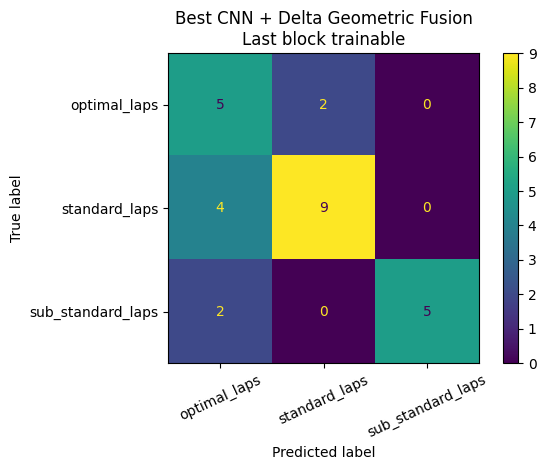

In [113]:
ConfusionMatrixDisplay.from_predictions(
    winning_true_labels,
    winning_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    values_format="d",
)

plt.title(
    "Best CNN + Delta Geometric Fusion\n"
    f"{winning_model_name}"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [114]:
checkpoint_comparison_path = (
    manifest_dir
    / "cnn-checkpoint-geometric-fusion-comparison.csv"
)

checkpoint_geometric_comparison.to_csv(
    checkpoint_comparison_path,
    index=False,
)


winning_fusion_df = (
    winning_result[
        "fusion_df"
    ][[
        "global_lap_num",
        "session",
        "session_lap_num",
        "class_name",
        "class_index",
    ]]
    .copy()
)

winning_fusion_df[
    "geometric_predicted_class_index"
] = winning_predictions

winning_fusion_df[
    "geometric_probability_optimal"
] = winning_probabilities[:, 0]

winning_fusion_df[
    "geometric_probability_standard"
] = winning_probabilities[:, 1]

winning_fusion_df[
    "geometric_probability_sub_standard"
] = winning_probabilities[:, 2]

winning_fusion_df[
    "cnn_model"
] = winning_model_name

winning_fusion_df[
    "cnn_weight"
] = winning_cnn_weight

winning_fusion_df[
    "delta_weight"
] = winning_delta_weight


winning_validation_path = (
    manifest_dir
    / "best-geometric-fusion-validation-results.csv"
)

winning_fusion_df.to_csv(
    winning_validation_path,
    index=False,
)

print(
    "Saved checkpoint comparison:",
    checkpoint_comparison_path,
)

print(
    "Saved winning validation results:",
    winning_validation_path,
)

Saved checkpoint comparison: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\cnn-checkpoint-geometric-fusion-comparison.csv
Saved winning validation results: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\best-geometric-fusion-validation-results.csv


Across the four CNN checkpoints, last-block fine-tuning combined with geometric probability fusion produced the strongest validation result, achieving 70.37% accuracy and 70.70% balanced accuracy.

## 12 Final untouched test evaluation

- CNN checkpoint: best_resnet18_last_block_throttle.pth
- CNN input: two throttle images averaged per lap
- Delta model: logistic regression trained on the 111 training laps
- Fusion: geometric probability fusion
- CNN weight: 0.37
- Delta weight: 0.63

### 12.1 Final Configuration

In [115]:
FINAL_CNN_MODEL_NAME = (
    "Last block trainable"
)

FINAL_CNN_CHECKPOINT = (
    project_root
    / "Code"
    / "best_resnet18_last_block_throttle.pth"
)

FINAL_CNN_WEIGHT = 0.37
FINAL_DELTA_WEIGHT = 0.63

assert np.isclose(
    FINAL_CNN_WEIGHT
    + FINAL_DELTA_WEIGHT,
    1.0,
)

if not FINAL_CNN_CHECKPOINT.exists():
    raise FileNotFoundError(
        "The selected final CNN checkpoint "
        "was not found:\n"
        f"{FINAL_CNN_CHECKPOINT}"
    )

print(
    "Final CNN:",
    FINAL_CNN_MODEL_NAME,
)

print(
    "Final checkpoint:",
    FINAL_CNN_CHECKPOINT,
)

print(
    "Locked CNN weight:",
    FINAL_CNN_WEIGHT,
)

print(
    "Locked delta weight:",
    FINAL_DELTA_WEIGHT,
)

Final CNN: Last block trainable
Final checkpoint: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Code\best_resnet18_last_block_throttle.pth
Locked CNN weight: 0.37
Locked delta weight: 0.63


### 12.2 Load the selected CNN checkpoint

In [116]:
final_test_cnn = models.resnet18(
    weights=None,
)

final_test_cnn.fc = nn.Linear(
    final_test_cnn.fc.in_features,
    num_classes,
)

final_test_cnn.load_state_dict(
    torch.load(
        FINAL_CNN_CHECKPOINT,
        map_location=device,
        weights_only=True,
    )
)

final_test_cnn = final_test_cnn.to(
    device
)

final_test_cnn.eval()

print(
    "Loaded final CNN checkpoint."
)

Loaded final CNN checkpoint.


### 12.3 Generate throttle-only CNN test probabilities

In [117]:
test_image_results = (
    collect_image_probabilities(
        final_test_cnn,
        test_loader,
        test_image_df,
    )
)

test_throttle_results = (
    aggregate_throttle_probabilities(
        test_image_results
    )
)

assert len(test_throttle_results) == len(
    test_lap_df
)

assert len(test_throttle_results) == 31

test_cnn_probability_columns = [
    "throttle_probability_optimal",
    "throttle_probability_standard",
    "throttle_probability_sub_standard",
]

test_cnn_probabilities = (
    test_throttle_results[
        test_cnn_probability_columns
    ]
    .to_numpy()
)

test_cnn_true_labels = (
    test_throttle_results[
        "class_index"
    ].to_numpy()
)

test_cnn_predictions = (
    test_cnn_probabilities.argmax(
        axis=1
    )
)

test_cnn_accuracy = accuracy_score(
    test_cnn_true_labels,
    test_cnn_predictions,
)

test_cnn_balanced_accuracy = (
    balanced_accuracy_score(
        test_cnn_true_labels,
        test_cnn_predictions,
    )
)

print(
    "Throttle CNN test accuracy:",
    f"{test_cnn_accuracy:.4f}",
)

print(
    "Throttle CNN test balanced accuracy:",
    f"{test_cnn_balanced_accuracy:.4f}",
)

Throttle CNN test accuracy: 0.5806
Throttle CNN test balanced accuracy: 0.6139


### 12.4 Refit the locked delta model using training data only

In [118]:
X_delta_test = (
    delta_test_df[
        delta_feature_columns
    ]
    .to_numpy()
)

y_delta_test = (
    delta_test_df[
        "class_index"
    ]
    .to_numpy()
)

assert len(delta_test_df) == 31

assert np.isfinite(
    X_delta_test
).all()

final_delta_model = Pipeline([
    (
        "scaler",
        StandardScaler(),
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=5000,
            class_weight="balanced",
            random_state=seed,
        ),
    ),
])

final_delta_model.fit(
    X_delta_train,
    y_delta_train,
)

final_delta_class_order = (
    final_delta_model.named_steps[
        "classifier"
    ].classes_
)

assert np.array_equal(
    final_delta_class_order,
    np.arange(num_classes),
)

test_delta_probabilities = (
    final_delta_model.predict_proba(
        X_delta_test
    )
)

test_delta_predictions = (
    test_delta_probabilities.argmax(
        axis=1
    )
)

test_delta_accuracy = accuracy_score(
    y_delta_test,
    test_delta_predictions,
)

test_delta_balanced_accuracy = (
    balanced_accuracy_score(
        y_delta_test,
        test_delta_predictions,
    )
)

print(
    "Delta test accuracy:",
    f"{test_delta_accuracy:.4f}",
)

print(
    "Delta test balanced accuracy:",
    f"{test_delta_balanced_accuracy:.4f}",
)

Delta test accuracy: 0.4194
Delta test balanced accuracy: 0.4250


### 12.5 Merge the CNN and delta test rows

In [119]:
test_delta_probability_df = pd.DataFrame({
    "global_lap_num":
        delta_test_df[
            "global_lap_num"
        ].to_numpy(),

    "delta_true_class_index":
        y_delta_test,

    "delta_predicted_class_index":
        test_delta_predictions,

    "delta_probability_optimal":
        test_delta_probabilities[:, 0],

    "delta_probability_standard":
        test_delta_probabilities[:, 1],

    "delta_probability_sub_standard":
        test_delta_probabilities[:, 2],
})


test_fusion_df = (
    test_throttle_results
    .merge(
        test_delta_probability_df,
        on="global_lap_num",
        how="inner",
        validate="one_to_one",
    )
    .sort_values(
        "global_lap_num"
    )
    .reset_index(drop=True)
)

assert len(test_fusion_df) == 31

assert (
    test_fusion_df[
        "class_index"
    ].to_numpy()
    == test_fusion_df[
        "delta_true_class_index"
    ].to_numpy()
).all()

test_true_labels = (
    test_fusion_df[
        "class_index"
    ].to_numpy()
)

test_cnn_probabilities = (
    test_fusion_df[[
        "throttle_probability_optimal",
        "throttle_probability_standard",
        "throttle_probability_sub_standard",
    ]]
    .to_numpy()
)

test_delta_probabilities = (
    test_fusion_df[[
        "delta_probability_optimal",
        "delta_probability_standard",
        "delta_probability_sub_standard",
    ]]
    .to_numpy()
)

print(
    "Test laps available for final fusion:",
    len(test_fusion_df),
)

Test laps available for final fusion: 31


### 12.6 Apply the locked geometric fusion

In [120]:
def fixed_geometric_probability_fusion(
    cnn_probabilities,
    delta_probabilities,
    cnn_weight,
    delta_weight,
    epsilon=1e-8,
):
    combined_log_probabilities = (
        cnn_weight
        * np.log(
            cnn_probabilities
            + epsilon
        )
        + delta_weight
        * np.log(
            delta_probabilities
            + epsilon
        )
    )

    combined_log_probabilities = (
        combined_log_probabilities
        - combined_log_probabilities.max(
            axis=1,
            keepdims=True,
        )
    )

    combined_probabilities = np.exp(
        combined_log_probabilities
    )

    combined_probabilities = (
        combined_probabilities
        / combined_probabilities.sum(
            axis=1,
            keepdims=True,
        )
    )

    return combined_probabilities


final_test_probabilities = (
    fixed_geometric_probability_fusion(
        cnn_probabilities=(
            test_cnn_probabilities
        ),
        delta_probabilities=(
            test_delta_probabilities
        ),
        cnn_weight=(
            FINAL_CNN_WEIGHT
        ),
        delta_weight=(
            FINAL_DELTA_WEIGHT
        ),
    )
)

final_test_predictions = (
    final_test_probabilities.argmax(
        axis=1
    )
)

final_test_accuracy = accuracy_score(
    test_true_labels,
    final_test_predictions,
)

final_test_balanced_accuracy = (
    balanced_accuracy_score(
        test_true_labels,
        final_test_predictions,
    )
)

print(
    "Final geometric fusion test accuracy:",
    f"{final_test_accuracy:.4f}",
)

print(
    "Final geometric fusion test "
    "balanced accuracy:",
    f"{final_test_balanced_accuracy:.4f}",
)

print(
    "Correct test laps:",
    int(
        (
            final_test_predictions
            == test_true_labels
        ).sum()
    ),
    "/",
    len(test_true_labels),
)

Final geometric fusion test accuracy: 0.5161
Final geometric fusion test balanced accuracy: 0.5500
Correct test laps: 16 / 31


### 12.7 Test-set majority baseline

In [121]:
final_majority_class_index = int(
    np.bincount(
        y_delta_train,
        minlength=num_classes,
    ).argmax()
)

final_majority_test_predictions = np.full(
    shape=len(test_true_labels),
    fill_value=final_majority_class_index,
    dtype=int,
)

final_majority_test_accuracy = (
    accuracy_score(
        test_true_labels,
        final_majority_test_predictions,
    )
)

final_majority_test_balanced_accuracy = (
    balanced_accuracy_score(
        test_true_labels,
        final_majority_test_predictions,
    )
)

### 12.8 Compare all final test models

In [122]:
final_test_comparison = pd.DataFrame({
    "model": [
        "Majority baseline",
        "Throttle-only CNN",
        "Delta logistic regression",
        "CNN + delta geometric fusion",
    ],

    "accuracy": [
        final_majority_test_accuracy,
        accuracy_score(
            test_true_labels,
            test_cnn_probabilities.argmax(
                axis=1
            ),
        ),
        accuracy_score(
            test_true_labels,
            test_delta_probabilities.argmax(
                axis=1
            ),
        ),
        final_test_accuracy,
    ],

    "balanced_accuracy": [
        final_majority_test_balanced_accuracy,
        balanced_accuracy_score(
            test_true_labels,
            test_cnn_probabilities.argmax(
                axis=1
            ),
        ),
        balanced_accuracy_score(
            test_true_labels,
            test_delta_probabilities.argmax(
                axis=1
            ),
        ),
        final_test_balanced_accuracy,
    ],
})

display(
    final_test_comparison
)

,model,accuracy,balanced_accuracy
0,Majority baseline,0.483871,0.333333
1,Throttle-only CNN,0.580645,0.613889
2,Delta logistic regression,0.419355,0.425000
3,CNN + delta geometric fusion,0.516129,0.550000


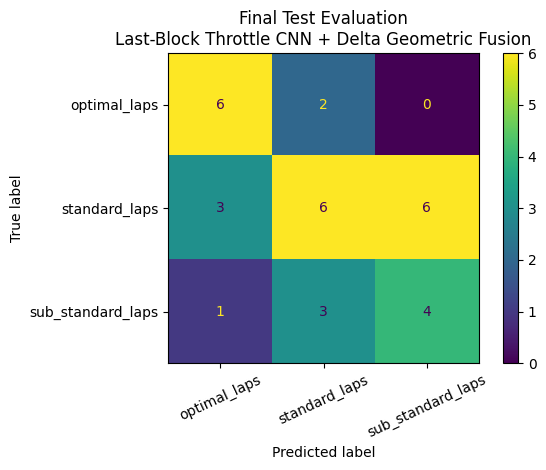

In [123]:
ConfusionMatrixDisplay.from_predictions(
    test_true_labels,
    final_test_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    values_format="d",
)

plt.title(
    "Final Test Evaluation\n"
    "Last-Block Throttle CNN + "
    "Delta Geometric Fusion"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [125]:
final_test_results = (
    test_fusion_df[[
        "global_lap_num",
        "session",
        "session_lap_num",
        "class_name",
        "class_index",
    ]]
    .copy()
)

final_test_results[
    "cnn_predicted_class_index"
] = test_cnn_probabilities.argmax(
    axis=1
)

final_test_results[
    "delta_predicted_class_index"
] = test_delta_probabilities.argmax(
    axis=1
)

final_test_results[
    "fusion_predicted_class_index"
] = final_test_predictions

final_test_results[
    "fusion_predicted_class_name"
] = [
    class_names[class_index]
    for class_index
    in final_test_predictions
]

final_test_results[
    "fusion_probability_optimal"
] = final_test_probabilities[:, 0]

final_test_results[
    "fusion_probability_standard"
] = final_test_probabilities[:, 1]

final_test_results[
    "fusion_probability_sub_standard"
] = final_test_probabilities[:, 2]

final_test_results[
    "correct"
] = (
    final_test_predictions
    == test_true_labels
)

final_test_results[
    "cnn_model"
] = FINAL_CNN_MODEL_NAME

final_test_results[
    "cnn_weight"
] = FINAL_CNN_WEIGHT

final_test_results[
    "delta_weight"
] = FINAL_DELTA_WEIGHT


final_test_results_path = (
    manifest_dir
    / "final-geometric-fusion-test-results.csv"
)

final_test_summary_path = (
    manifest_dir
    / "final-test-model-comparison.csv"
)

final_test_results.to_csv(
    final_test_results_path,
    index=False,
)

final_test_comparison.to_csv(
    final_test_summary_path,
    index=False,
)

print(
    "Saved final test results:",
    final_test_results_path,
)

print(
    "Saved final test comparison:",
    final_test_summary_path,
)

Saved final test results: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\final-geometric-fusion-test-results.csv
Saved final test comparison: C:\Users\admin\Desktop\Summer Projects\F1\F1-Optimized-Cornering-Project\Data\manifests\final-test-model-comparison.csv


## Leave One Session Out Cross Validation
### LOSO Configuration


In [ ]:
LOSO_EPOCHS = 7

LOSO_LAST_BLOCK_LR = 2e-5
LOSO_CLASSIFIER_LR = 5e-4
LOSO_WEIGHT_DECAY = 1e-4

# Locked geometric-fusion weights.
LOSO_CNN_WEIGHT = 0.37
LOSO_DELTA_WEIGHT = 0.63

assert np.isclose(
    LOSO_CNN_WEIGHT + LOSO_DELTA_WEIGHT,
    1.0,
)

delta_feature_columns = [
    "delta_1_seconds",
    "delta_2_seconds",
]

loso_predictions_path = (
    manifest_dir
    / "loso-final-pipeline-oof-predictions.csv"
)

loso_fold_summary_path = (
    manifest_dir
    / "loso-final-pipeline-fold-summary.csv"
)

loso_overall_summary_path = (
    manifest_dir
    / "loso-final-pipeline-overall-summary.csv"
)

# When True, completed sessions found in the CSV files
# are skipped if the run is interrupted and restarted.
RESUME_LOSO = True

# loso_predictions_path.unlink(missing_ok=True)
# loso_fold_summary_path.unlink(missing_ok=True)

LOSO helper functions

In [127]:
def set_loso_seed(fold_seed):
    np.random.seed(fold_seed)
    torch.manual_seed(fold_seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            fold_seed
        )


def build_loso_last_block_model():
    """
    Fresh ImageNet-pretrained ResNet18 with only
    layer4[1] and the final classifier trainable.
    """
    fold_model = models.resnet18(
        weights=weights
    )

    for parameter in fold_model.parameters():
        parameter.requires_grad = False

    fold_model.fc = nn.Linear(
        fold_model.fc.in_features,
        num_classes,
    )

    for parameter in (
        fold_model.layer4[1].parameters()
    ):
        parameter.requires_grad = True

    for parameter in fold_model.fc.parameters():
        parameter.requires_grad = True

    # Freeze BatchNorm parameters in the last block.
    for module in (
        fold_model.layer4[1].modules()
    ):
        if isinstance(module, nn.BatchNorm2d):
            for parameter in module.parameters():
                parameter.requires_grad = False

    return fold_model.to(device)


def calculate_fold_class_weights(
    fold_training_laps,
):
    """
    Square-root inverse-frequency weights,
    calculated separately within each fold.
    """
    class_counts = (
        fold_training_laps["class_index"]
        .value_counts()
        .reindex(
            range(num_classes),
            fill_value=0,
        )
    )

    if class_counts.eq(0).any():
        raise ValueError(
            "A LOSO training fold is missing "
            "at least one class."
        )

    inverse_frequency = (
        len(fold_training_laps)
        / (
            num_classes
            * class_counts.to_numpy()
        )
    )

    fold_weights = np.sqrt(
        inverse_frequency
    )

    fold_weights = (
        fold_weights
        / fold_weights.mean()
    )

    return torch.tensor(
        fold_weights,
        dtype=torch.float32,
        device=device,
    )


def train_loso_cnn_epoch(
    fold_model,
    fold_loader,
    fold_criterion,
    fold_optimizer,
):
    fold_model.eval()

    fold_model.layer4[1].train()
    fold_model.fc.train()

    # Keep BatchNorm running statistics fixed.
    for module in (
        fold_model.layer4[1].modules()
    ):
        if isinstance(module, nn.BatchNorm2d):
            module.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    for inputs, labels in fold_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        fold_optimizer.zero_grad()

        logits = fold_model(inputs)

        loss = fold_criterion(
            logits,
            labels,
        )

        loss.backward()
        fold_optimizer.step()

        running_loss += (
            loss.item()
            * inputs.size(0)
        )

        predictions = logits.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total,
    )


def fixed_geometric_fusion(
    cnn_probabilities,
    delta_probabilities,
    cnn_weight=LOSO_CNN_WEIGHT,
    delta_weight=LOSO_DELTA_WEIGHT,
    epsilon=1e-8,
):
    combined_log_probabilities = (
        cnn_weight
        * np.log(
            cnn_probabilities + epsilon
        )
        + delta_weight
        * np.log(
            delta_probabilities + epsilon
        )
    )

    combined_log_probabilities = (
        combined_log_probabilities
        - combined_log_probabilities.max(
            axis=1,
            keepdims=True,
        )
    )

    combined_probabilities = np.exp(
        combined_log_probabilities
    )

    return (
        combined_probabilities
        / combined_probabilities.sum(
            axis=1,
            keepdims=True,
        )
    )

### 13.2 Identify the LOSO folds

In [128]:
complete_delta_laps = (
    lap_manifest[
        lap_manifest["has_delta_data"]
    ]
    .copy()
    .reset_index(drop=True)
)

session_delta_status = (
    lap_manifest
    .groupby("session")[
        "has_delta_data"
    ]
    .all()
)

loso_sessions = [
    int(session)
    for session in (
        session_delta_status[
            session_delta_status
        ].index
    )
]

loso_sessions = sorted(
    loso_sessions
)

print(
    "LOSO held-out sessions:",
    loso_sessions,
)

print(
    "Number of LOSO folds:",
    len(loso_sessions),
)

print(
    "Complete-delta laps receiving "
    "out-of-fold predictions:",
    len(complete_delta_laps),
)

assert loso_sessions == list(
    range(6, 26)
)

assert len(complete_delta_laps) == 169

LOSO held-out sessions: [6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]
Number of LOSO folds: 20
Complete-delta laps receiving out-of-fold predictions: 169


### 13.3 Load any partially completed run

In [129]:
if (
    RESUME_LOSO
    and loso_predictions_path.exists()
    and loso_fold_summary_path.exists()
):
    existing_loso_predictions = pd.read_csv(
        loso_predictions_path
    )

    existing_loso_fold_summary = pd.read_csv(
        loso_fold_summary_path
    )

    completed_loso_sessions = set(
        existing_loso_fold_summary[
            "held_out_session"
        ].astype(int)
    )

    print(
        "Resuming after completed sessions:",
        sorted(completed_loso_sessions),
    )

elif (
    loso_predictions_path.exists()
    != loso_fold_summary_path.exists()
):
    raise RuntimeError(
        "Only one LOSO output file exists. "
        "Delete both LOSO files and restart, "
        "or restore the missing file."
    )

else:
    existing_loso_predictions = (
        pd.DataFrame()
    )

    existing_loso_fold_summary = (
        pd.DataFrame()
    )

    completed_loso_sessions = set()

### 13.4 Run the 20 LOSO folds

In [130]:
for fold_number, held_out_session in enumerate(
    loso_sessions,
    start=1,
):
    if held_out_session in (
        completed_loso_sessions
    ):
        print(
            f"Skipping completed session "
            f"{held_out_session}."
        )
        continue

    print("\n" + "=" * 80)

    print(
        f"Fold {fold_number:02d}/"
        f"{len(loso_sessions)} | "
        f"Held-out session: "
        f"{held_out_session}"
    )

    print("=" * 80)

    fold_seed = seed + held_out_session

    set_loso_seed(fold_seed)

    # -------------------------------------------------
    # CNN data
    # -------------------------------------------------

    # Sessions 1–5 remain available here because
    # images and class labels exist for them.
    fold_cnn_training_laps = (
        lap_manifest[
            lap_manifest["session"]
            != held_out_session
        ]
        .copy()
        .reset_index(drop=True)
    )

    fold_cnn_training_images = (
        image_manifest[
            image_manifest["session"]
            != held_out_session
        ]
        .copy()
        .reset_index(drop=True)
    )

    fold_held_out_images = (
        image_manifest[
            image_manifest["session"]
            == held_out_session
        ]
        .copy()
        .reset_index(drop=True)
    )

    # The held-out fusion laps must have deltas.
    fold_held_out_laps = (
        complete_delta_laps[
            complete_delta_laps["session"]
            == held_out_session
        ]
        .copy()
        .reset_index(drop=True)
    )

    assert len(
        fold_held_out_images
    ) == 4 * len(
        fold_held_out_laps
    )

    fold_training_dataset = (
        ManifestImageDataset(
            fold_cnn_training_images,
            project_root,
            train_transform,
        )
    )

    fold_held_out_dataset = (
        ManifestImageDataset(
            fold_held_out_images,
            project_root,
            eval_transform,
        )
    )

    fold_generator = (
        torch.Generator()
        .manual_seed(fold_seed)
    )

    fold_training_loader = DataLoader(
        fold_training_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        generator=fold_generator,
    )

    fold_held_out_loader = DataLoader(
        fold_held_out_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    # -------------------------------------------------
    # Fresh CNN for this fold
    # -------------------------------------------------

    fold_model = (
        build_loso_last_block_model()
    )

    fold_class_weights = (
        calculate_fold_class_weights(
            fold_cnn_training_laps
        )
    )

    fold_criterion = nn.CrossEntropyLoss(
        weight=fold_class_weights,
    )

    fold_last_block_parameters = [
        parameter
        for parameter
        in fold_model.layer4[1].parameters()
        if parameter.requires_grad
    ]

    fold_optimizer = optim.Adam(
        [
            {
                "params":
                    fold_last_block_parameters,

                "lr":
                    LOSO_LAST_BLOCK_LR,
            },
            {
                "params":
                    fold_model.fc.parameters(),

                "lr":
                    LOSO_CLASSIFIER_LR,
            },
        ],
        weight_decay=LOSO_WEIGHT_DECAY,
    )

    final_fold_train_loss = None
    final_fold_train_accuracy = None

    for epoch in range(LOSO_EPOCHS):
        (
            final_fold_train_loss,
            final_fold_train_accuracy,
        ) = train_loso_cnn_epoch(
            fold_model,
            fold_training_loader,
            fold_criterion,
            fold_optimizer,
        )

        print(
            f"  Epoch {epoch + 1}/"
            f"{LOSO_EPOCHS} | "
            f"Loss: "
            f"{final_fold_train_loss:.4f} | "
            f"Image accuracy: "
            f"{final_fold_train_accuracy:.4f}"
        )

    # -------------------------------------------------
    # Held-out throttle CNN probabilities
    # -------------------------------------------------

    fold_image_results = (
        collect_image_probabilities(
            fold_model,
            fold_held_out_loader,
            fold_held_out_images,
        )
    )

    fold_throttle_results = (
        aggregate_throttle_probabilities(
            fold_image_results
        )
    )

    assert len(
        fold_throttle_results
    ) == len(
        fold_held_out_laps
    )

    # -------------------------------------------------
    # Delta model for this fold
    # -------------------------------------------------

    fold_delta_training_laps = (
        complete_delta_laps[
            complete_delta_laps["session"]
            != held_out_session
        ]
        .copy()
        .reset_index(drop=True)
    )

    X_fold_delta_train = (
        fold_delta_training_laps[
            delta_feature_columns
        ]
        .to_numpy()
    )

    y_fold_delta_train = (
        fold_delta_training_laps[
            "class_index"
        ]
        .to_numpy()
    )

    X_fold_delta_test = (
        fold_held_out_laps[
            delta_feature_columns
        ]
        .to_numpy()
    )

    y_fold_delta_test = (
        fold_held_out_laps[
            "class_index"
        ]
        .to_numpy()
    )

    assert np.isfinite(
        X_fold_delta_train
    ).all()

    assert np.isfinite(
        X_fold_delta_test
    ).all()

    fold_delta_model = Pipeline([
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "classifier",
            LogisticRegression(
                max_iter=5000,
                class_weight="balanced",
                random_state=fold_seed,
            ),
        ),
    ])

    fold_delta_model.fit(
        X_fold_delta_train,
        y_fold_delta_train,
    )

    fold_delta_classes = (
        fold_delta_model.named_steps[
            "classifier"
        ].classes_
    )

    assert np.array_equal(
        fold_delta_classes,
        np.arange(num_classes),
    )

    fold_delta_probabilities = (
        fold_delta_model.predict_proba(
            X_fold_delta_test
        )
    )

    fold_delta_probability_df = (
        pd.DataFrame({
            "global_lap_num":
                fold_held_out_laps[
                    "global_lap_num"
                ].to_numpy(),

            "delta_true_class_index":
                y_fold_delta_test,

            "delta_probability_optimal":
                fold_delta_probabilities[:, 0],

            "delta_probability_standard":
                fold_delta_probabilities[:, 1],

            "delta_probability_sub_standard":
                fold_delta_probabilities[:, 2],
        })
    )

    # -------------------------------------------------
    # Merge the two modalities
    # -------------------------------------------------

    fold_fusion_df = (
        fold_throttle_results
        .merge(
            fold_delta_probability_df,
            on="global_lap_num",
            how="inner",
            validate="one_to_one",
        )
        .sort_values("global_lap_num")
        .reset_index(drop=True)
    )

    assert len(fold_fusion_df) == len(
        fold_held_out_laps
    )

    assert (
        fold_fusion_df[
            "class_index"
        ].to_numpy()
        == fold_fusion_df[
            "delta_true_class_index"
        ].to_numpy()
    ).all()

    fold_true_labels = (
        fold_fusion_df[
            "class_index"
        ].to_numpy()
    )

    fold_cnn_probabilities = (
        fold_fusion_df[[
            "throttle_probability_optimal",
            "throttle_probability_standard",
            "throttle_probability_sub_standard",
        ]]
        .to_numpy()
    )

    fold_delta_probabilities = (
        fold_fusion_df[[
            "delta_probability_optimal",
            "delta_probability_standard",
            "delta_probability_sub_standard",
        ]]
        .to_numpy()
    )

    fold_fusion_probabilities = (
        fixed_geometric_fusion(
            fold_cnn_probabilities,
            fold_delta_probabilities,
        )
    )

    fold_cnn_predictions = (
        fold_cnn_probabilities.argmax(
            axis=1
        )
    )

    fold_delta_predictions = (
        fold_delta_probabilities.argmax(
            axis=1
        )
    )

    fold_fusion_predictions = (
        fold_fusion_probabilities.argmax(
            axis=1
        )
    )

    fold_majority_class = int(
        np.bincount(
            y_fold_delta_train,
            minlength=num_classes,
        ).argmax()
    )

    fold_majority_predictions = np.full(
        len(fold_true_labels),
        fold_majority_class,
        dtype=int,
    )

    # -------------------------------------------------
    # Save the held-out predictions
    # -------------------------------------------------

    fold_prediction_output = pd.DataFrame({
        "held_out_session":
            held_out_session,

        "global_lap_num":
            fold_fusion_df[
                "global_lap_num"
            ].to_numpy(),

        "session_lap_num":
            fold_fusion_df[
                "session_lap_num"
            ].to_numpy(),

        "class_name":
            fold_fusion_df[
                "class_name"
            ].to_numpy(),

        "class_index":
            fold_true_labels,

        "majority_predicted_class_index":
            fold_majority_predictions,

        "cnn_predicted_class_index":
            fold_cnn_predictions,

        "delta_predicted_class_index":
            fold_delta_predictions,

        "fusion_predicted_class_index":
            fold_fusion_predictions,

        "cnn_probability_optimal":
            fold_cnn_probabilities[:, 0],

        "cnn_probability_standard":
            fold_cnn_probabilities[:, 1],

        "cnn_probability_sub_standard":
            fold_cnn_probabilities[:, 2],

        "delta_probability_optimal":
            fold_delta_probabilities[:, 0],

        "delta_probability_standard":
            fold_delta_probabilities[:, 1],

        "delta_probability_sub_standard":
            fold_delta_probabilities[:, 2],

        "fusion_probability_optimal":
            fold_fusion_probabilities[:, 0],

        "fusion_probability_standard":
            fold_fusion_probabilities[:, 1],

        "fusion_probability_sub_standard":
            fold_fusion_probabilities[:, 2],
    })

    fold_summary_output = pd.DataFrame([{
        "held_out_session":
            held_out_session,

        "held_out_laps":
            len(fold_true_labels),

        "held_out_classes":
            len(np.unique(
                fold_true_labels
            )),

        "cnn_accuracy":
            accuracy_score(
                fold_true_labels,
                fold_cnn_predictions,
            ),

        "cnn_balanced_accuracy":
            balanced_accuracy_score(
                fold_true_labels,
                fold_cnn_predictions,
            ),

        "delta_accuracy":
            accuracy_score(
                fold_true_labels,
                fold_delta_predictions,
            ),

        "delta_balanced_accuracy":
            balanced_accuracy_score(
                fold_true_labels,
                fold_delta_predictions,
            ),

        "fusion_accuracy":
            accuracy_score(
                fold_true_labels,
                fold_fusion_predictions,
            ),

        "fusion_balanced_accuracy":
            balanced_accuracy_score(
                fold_true_labels,
                fold_fusion_predictions,
            ),

        "final_cnn_train_loss":
            final_fold_train_loss,

        "final_cnn_train_image_accuracy":
            final_fold_train_accuracy,
    }])

    existing_loso_predictions = (
        pd.concat(
            [
                existing_loso_predictions,
                fold_prediction_output,
            ],
            ignore_index=True,
        )
        .drop_duplicates(
            subset=["global_lap_num"],
            keep="last",
        )
        .sort_values("global_lap_num")
        .reset_index(drop=True)
    )

    existing_loso_fold_summary = (
        pd.concat(
            [
                existing_loso_fold_summary,
                fold_summary_output,
            ],
            ignore_index=True,
        )
        .drop_duplicates(
            subset=["held_out_session"],
            keep="last",
        )
        .sort_values("held_out_session")
        .reset_index(drop=True)
    )

    existing_loso_predictions.to_csv(
        loso_predictions_path,
        index=False,
    )

    existing_loso_fold_summary.to_csv(
        loso_fold_summary_path,
        index=False,
    )

    print(
        f"  Saved fold {held_out_session}. "
        f"Fusion accuracy: "
        f"{fold_summary_output.iloc[0]['fusion_accuracy']:.4f}"
    )

    completed_loso_sessions.add(
        held_out_session
    )

    # Release GPU memory before the next fold.
    del fold_model
    del fold_optimizer
    del fold_criterion
    del fold_training_loader
    del fold_held_out_loader
    del fold_training_dataset
    del fold_held_out_dataset

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


Fold 01/20 | Held-out session: 6
  Epoch 1/7 | Loss: 1.0999 | Image accuracy: 0.4388
  Epoch 2/7 | Loss: 1.0226 | Image accuracy: 0.4948
  Epoch 3/7 | Loss: 0.9876 | Image accuracy: 0.5573
  Epoch 4/7 | Loss: 0.9534 | Image accuracy: 0.5612
  Epoch 5/7 | Loss: 0.9236 | Image accuracy: 0.5964
  Epoch 6/7 | Loss: 0.8885 | Image accuracy: 0.6055
  Epoch 7/7 | Loss: 0.8652 | Image accuracy: 0.6211
  Saved fold 6. Fusion accuracy: 0.6000

Fold 02/20 | Held-out session: 7
  Epoch 1/7 | Loss: 1.1030 | Image accuracy: 0.4424
  Epoch 2/7 | Loss: 1.0257 | Image accuracy: 0.5052
  Epoch 3/7 | Loss: 0.9921 | Image accuracy: 0.5105
  Epoch 4/7 | Loss: 0.9499 | Image accuracy: 0.5654
  Epoch 5/7 | Loss: 0.9074 | Image accuracy: 0.6178
  Epoch 6/7 | Loss: 0.8804 | Image accuracy: 0.6191
  Epoch 7/7 | Loss: 0.8510 | Image accuracy: 0.6230
  Saved fold 7. Fusion accuracy: 0.6667

Fold 03/20 | Held-out session: 8
  Epoch 1/7 | Loss: 1.1195 | Image accuracy: 0.4202
  Epoch 2/7 | Loss: 1.0422 | Image acc

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Saved fold 8. Fusion accuracy: 0.3333

Fold 04/20 | Held-out session: 9
  Epoch 1/7 | Loss: 1.1061 | Image accuracy: 0.4485
  Epoch 2/7 | Loss: 1.0265 | Image accuracy: 0.5039
  Epoch 3/7 | Loss: 1.0061 | Image accuracy: 0.5142
  Epoch 4/7 | Loss: 0.9690 | Image accuracy: 0.5399
  Epoch 5/7 | Loss: 0.9336 | Image accuracy: 0.5747
  Epoch 6/7 | Loss: 0.8953 | Image accuracy: 0.6160
  Epoch 7/7 | Loss: 0.8557 | Image accuracy: 0.6263
  Saved fold 9. Fusion accuracy: 1.0000

Fold 05/20 | Held-out session: 10
  Epoch 1/7 | Loss: 1.1195 | Image accuracy: 0.4194
  Epoch 2/7 | Loss: 1.0363 | Image accuracy: 0.4946
  Epoch 3/7 | Loss: 0.9939 | Image accuracy: 0.5349
  Epoch 4/7 | Loss: 0.9638 | Image accuracy: 0.5242
  Epoch 5/7 | Loss: 0.9282 | Image accuracy: 0.5874
  Epoch 6/7 | Loss: 0.9163 | Image accuracy: 0.5766
  Epoch 7/7 | Loss: 0.8837 | Image accuracy: 0.6062
  Saved fold 10. Fusion accuracy: 0.6364

Fold 06/20 | Held-out session: 11
  Epoch 1/7 | Loss: 1.1133 | Image accuracy: 0.

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Saved fold 11. Fusion accuracy: 0.5000

Fold 07/20 | Held-out session: 12
  Epoch 1/7 | Loss: 1.1728 | Image accuracy: 0.3902
  Epoch 2/7 | Loss: 1.0317 | Image accuracy: 0.5225
  Epoch 3/7 | Loss: 0.9930 | Image accuracy: 0.5291
  Epoch 4/7 | Loss: 0.9616 | Image accuracy: 0.5265
  Epoch 5/7 | Loss: 0.9365 | Image accuracy: 0.5648
  Epoch 6/7 | Loss: 0.9133 | Image accuracy: 0.5860
  Epoch 7/7 | Loss: 0.8698 | Image accuracy: 0.6111
  Saved fold 12. Fusion accuracy: 0.7500

Fold 08/20 | Held-out session: 13
  Epoch 1/7 | Loss: 1.1269 | Image accuracy: 0.4323
  Epoch 2/7 | Loss: 1.0337 | Image accuracy: 0.4844
  Epoch 3/7 | Loss: 0.9951 | Image accuracy: 0.4948
  Epoch 4/7 | Loss: 0.9509 | Image accuracy: 0.5807
  Epoch 5/7 | Loss: 0.9278 | Image accuracy: 0.5638
  Epoch 6/7 | Loss: 0.9086 | Image accuracy: 0.5768
  Epoch 7/7 | Loss: 0.8656 | Image accuracy: 0.6185
  Saved fold 13. Fusion accuracy: 0.8000

Fold 09/20 | Held-out session: 14
  Epoch 1/7 | Loss: 1.0990 | Image accuracy:

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Saved fold 14. Fusion accuracy: 0.8571

Fold 10/20 | Held-out session: 15
  Epoch 1/7 | Loss: 1.1191 | Image accuracy: 0.3984
  Epoch 2/7 | Loss: 1.0253 | Image accuracy: 0.5143
  Epoch 3/7 | Loss: 0.9935 | Image accuracy: 0.5430
  Epoch 4/7 | Loss: 0.9529 | Image accuracy: 0.5768
  Epoch 5/7 | Loss: 0.9184 | Image accuracy: 0.5885
  Epoch 6/7 | Loss: 0.8893 | Image accuracy: 0.6237
  Epoch 7/7 | Loss: 0.8518 | Image accuracy: 0.6497
  Saved fold 15. Fusion accuracy: 0.6000

Fold 11/20 | Held-out session: 16
  Epoch 1/7 | Loss: 1.1177 | Image accuracy: 0.4140
  Epoch 2/7 | Loss: 1.0173 | Image accuracy: 0.5132
  Epoch 3/7 | Loss: 0.9880 | Image accuracy: 0.5370
  Epoch 4/7 | Loss: 0.9575 | Image accuracy: 0.5476
  Epoch 5/7 | Loss: 0.9267 | Image accuracy: 0.5807
  Epoch 6/7 | Loss: 0.8926 | Image accuracy: 0.6005
  Epoch 7/7 | Loss: 0.8590 | Image accuracy: 0.6402
  Saved fold 16. Fusion accuracy: 0.7500

Fold 12/20 | Held-out session: 17
  Epoch 1/7 | Loss: 1.1162 | Image accuracy:

c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
c:\Users\admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  Saved fold 18. Fusion accuracy: 0.4286

Fold 14/20 | Held-out session: 19
  Epoch 1/7 | Loss: 1.1263 | Image accuracy: 0.4097
  Epoch 2/7 | Loss: 1.0622 | Image accuracy: 0.4503
  Epoch 3/7 | Loss: 1.0339 | Image accuracy: 0.4908
  Epoch 4/7 | Loss: 0.9769 | Image accuracy: 0.5628
  Epoch 5/7 | Loss: 0.9487 | Image accuracy: 0.5471
  Epoch 6/7 | Loss: 0.9177 | Image accuracy: 0.6008
  Epoch 7/7 | Loss: 0.8803 | Image accuracy: 0.6257
  Saved fold 19. Fusion accuracy: 0.8333

Fold 15/20 | Held-out session: 20
  Epoch 1/7 | Loss: 1.1246 | Image accuracy: 0.4118
  Epoch 2/7 | Loss: 1.0299 | Image accuracy: 0.5174
  Epoch 3/7 | Loss: 1.0084 | Image accuracy: 0.5107
  Epoch 4/7 | Loss: 0.9550 | Image accuracy: 0.6003
  Epoch 5/7 | Loss: 0.9283 | Image accuracy: 0.5615
  Epoch 6/7 | Loss: 0.8898 | Image accuracy: 0.6056
  Epoch 7/7 | Loss: 0.8744 | Image accuracy: 0.6056
  Saved fold 20. Fusion accuracy: 0.5000

Fold 16/20 | Held-out session: 21
  Epoch 1/7 | Loss: 1.1207 | Image accuracy:

### 13.5 Validate the completed out-of-fold dataset

In [131]:
loso_oof_predictions = pd.read_csv(
    loso_predictions_path
)

loso_fold_summary = pd.read_csv(
    loso_fold_summary_path
)

assert len(loso_fold_summary) == len(
    loso_sessions
)

assert set(
    loso_fold_summary[
        "held_out_session"
    ].astype(int)
) == set(loso_sessions)

assert len(loso_oof_predictions) == len(
    complete_delta_laps
)

assert loso_oof_predictions[
    "global_lap_num"
].is_unique

assert set(
    loso_oof_predictions[
        "global_lap_num"
    ]
) == set(
    complete_delta_laps[
        "global_lap_num"
    ]
)

print(
    "LOSO validation passed."
)

print(
    "Out-of-fold laps:",
    len(loso_oof_predictions),
)

print(
    "Held-out sessions:",
    loso_fold_summary[
        "held_out_session"
    ].nunique(),
)

LOSO validation passed.
Out-of-fold laps: 169
Held-out sessions: 20


### 13.6 Overall LOSO comparison

In [132]:
loso_true_labels = (
    loso_oof_predictions[
        "class_index"
    ].to_numpy()
)

loso_model_prediction_columns = {
    "Fold-specific majority baseline":
        "majority_predicted_class_index",

    "Throttle-only CNN":
        "cnn_predicted_class_index",

    "Delta logistic regression":
        "delta_predicted_class_index",

    "CNN + delta geometric fusion":
        "fusion_predicted_class_index",
}

loso_comparison_records = []

for (
    model_name,
    prediction_column,
) in loso_model_prediction_columns.items():

    model_predictions = (
        loso_oof_predictions[
            prediction_column
        ].to_numpy()
    )

    loso_comparison_records.append({
        "model":
            model_name,

        "accuracy":
            accuracy_score(
                loso_true_labels,
                model_predictions,
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                loso_true_labels,
                model_predictions,
            ),

        "correct_laps":
            int(
                (
                    model_predictions
                    == loso_true_labels
                ).sum()
            ),

        "total_laps":
            len(loso_true_labels),
    })

loso_overall_comparison = (
    pd.DataFrame(
        loso_comparison_records
    )
    .sort_values(
        [
            "balanced_accuracy",
            "accuracy",
        ],
        ascending=False,
    )
    .reset_index(drop=True)
)

display(
    loso_overall_comparison
)

loso_overall_comparison.to_csv(
    loso_overall_summary_path,
    index=False,
)

,model,accuracy,balanced_accuracy,correct_laps,total_laps
0,CNN + delta geometric fusion,0.639053,0.664106,108,169
1,Delta logistic regression,0.538462,0.600480,91,169
2,Throttle-only CNN,0.627219,0.587915,106,169
3,Fold-specific majority baseline,0.502959,0.333333,85,169


                   precision    recall  f1-score   support

     optimal_laps     0.5636    0.6327    0.5962        49
    standard_laps     0.6944    0.5882    0.6369        85
sub_standard_laps     0.6429    0.7714    0.7013        35

         accuracy                         0.6391       169
        macro avg     0.6336    0.6641    0.6448       169
     weighted avg     0.6458    0.6391    0.6384       169



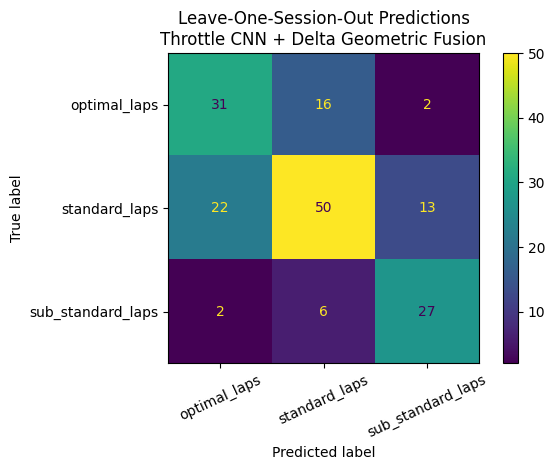

In [133]:
loso_fusion_predictions = (
    loso_oof_predictions[
        "fusion_predicted_class_index"
    ].to_numpy()
)

print(
    classification_report(
        loso_true_labels,
        loso_fusion_predictions,
        labels=list(range(num_classes)),
        target_names=class_names,
        zero_division=0,
        digits=4,
    )
)

ConfusionMatrixDisplay.from_predictions(
    loso_true_labels,
    loso_fusion_predictions,
    labels=list(range(num_classes)),
    display_labels=class_names,
    values_format="d",
)

plt.title(
    "Leave-One-Session-Out Predictions\n"
    "Throttle CNN + Delta Geometric Fusion"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [134]:
display(
    loso_fold_summary[[
        "held_out_session",
        "held_out_laps",
        "held_out_classes",
        "cnn_accuracy",
        "delta_accuracy",
        "fusion_accuracy",
        "cnn_balanced_accuracy",
        "delta_balanced_accuracy",
        "fusion_balanced_accuracy",
    ]]
)

,held_out_session,held_out_laps,held_out_classes,cnn_accuracy,delta_accuracy,fusion_accuracy,cnn_balanced_accuracy,delta_balanced_accuracy,fusion_balanced_accuracy
0,6,5,2,0.800000,0.600000,0.600000,0.500000,0.375000,0.375000
1,7,6,3,0.666667,0.833333,0.666667,0.500000,0.833333,0.500000
2,8,6,2,0.833333,0.166667,0.333333,0.900000,0.100000,0.200000
3,9,3,3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,10,11,3,0.454545,0.454545,0.636364,0.357143,0.714286,0.809524
5,11,4,2,0.250000,0.250000,0.500000,0.250000,0.250000,0.500000
6,12,8,3,0.625000,0.750000,0.750000,0.433333,0.766667,0.766667
7,13,5,3,0.600000,0.800000,0.800000,0.500000,0.666667,0.666667
8,14,7,2,0.428571,0.857143,0.857143,0.500000,0.833333,0.875000
9,15,5,3,0.600000,0.800000,0.600000,0.333333,0.666667,0.333333


In [135]:
display(
    loso_fold_summary.sort_values(
        "fusion_accuracy",
        ascending=True,
    )
)

,held_out_session,held_out_laps,held_out_classes,cnn_accuracy,cnn_balanced_accuracy,delta_accuracy,delta_balanced_accuracy,fusion_accuracy,fusion_balanced_accuracy,final_cnn_train_loss,final_cnn_train_image_accuracy
2,8,6,2,0.833333,0.900000,0.166667,0.100000,0.333333,0.200000,0.850692,0.621728
12,18,7,2,0.428571,0.375000,0.571429,0.625000,0.428571,0.458333,0.852459,0.650000
15,21,9,3,0.777778,0.777778,0.444444,0.444444,0.444444,0.444444,0.867327,0.617021
5,11,4,2,0.250000,0.250000,0.250000,0.250000,0.500000,0.500000,0.860279,0.637306
14,20,10,3,0.600000,0.611111,0.400000,0.416667,0.500000,0.500000,0.874366,0.605615
18,24,15,3,0.533333,0.527778,0.400000,0.402778,0.533333,0.527778,0.866474,0.630495
19,25,14,3,0.571429,0.551587,0.357143,0.337302,0.571429,0.551587,0.902014,0.583333
9,15,5,3,0.600000,0.333333,0.800000,0.666667,0.600000,0.333333,0.851778,0.649740
0,6,5,2,0.800000,0.500000,0.600000,0.375000,0.600000,0.375000,0.865224,0.621094
11,17,13,3,0.769231,0.666667,0.538462,0.750000,0.615385,0.791667,0.870147,0.618207


In [136]:
clean_fold_records = []

for held_out_session, session_predictions in (
    loso_oof_predictions
    .groupby("held_out_session")
):
    true_labels = (
        session_predictions[
            "class_index"
        ].to_numpy()
    )

    present_classes = np.unique(
        true_labels
    )

    session_record = {
        "held_out_session":
            int(held_out_session),

        "held_out_laps":
            len(true_labels),

        "held_out_classes":
            len(present_classes),

        "classes_present":
            ", ".join(
                class_names[class_index]
                for class_index
                in present_classes
            ),
    }

    prediction_columns = {
        "cnn":
            "cnn_predicted_class_index",

        "delta":
            "delta_predicted_class_index",

        "fusion":
            "fusion_predicted_class_index",
    }

    for model_name, column in (
        prediction_columns.items()
    ):
        predictions = (
            session_predictions[
                column
            ].to_numpy()
        )

        session_record[
            f"{model_name}_accuracy"
        ] = accuracy_score(
            true_labels,
            predictions,
        )

        if len(present_classes) == num_classes:
            session_record[
                f"{model_name}_balanced_accuracy"
            ] = balanced_accuracy_score(
                true_labels,
                predictions,
            )
        else:
            session_record[
                f"{model_name}_balanced_accuracy"
            ] = np.nan

    clean_fold_records.append(
        session_record
    )


clean_loso_fold_summary = (
    pd.DataFrame(
        clean_fold_records
    )
    .sort_values(
        "held_out_session"
    )
    .reset_index(drop=True)
)

display(
    clean_loso_fold_summary
)

,held_out_session,held_out_laps,held_out_classes,classes_present,cnn_accuracy,cnn_balanced_accuracy,delta_accuracy,delta_balanced_accuracy,fusion_accuracy,fusion_balanced_accuracy
0,6,5,2,"standard_laps, sub_standard_laps",0.800000,NaN,0.600000,NaN,0.600000,NaN
1,7,6,3,"optimal_laps, standard_laps, sub_standard_laps",0.666667,0.500000,0.833333,0.833333,0.666667,0.500000
2,8,6,2,"standard_laps, sub_standard_laps",0.833333,NaN,0.166667,NaN,0.333333,NaN
3,9,3,3,"optimal_laps, standard_laps, sub_standard_laps",1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
4,10,11,3,"optimal_laps, standard_laps, sub_standard_laps",0.454545,0.357143,0.454545,0.714286,0.636364,0.809524
5,11,4,2,"standard_laps, sub_standard_laps",0.250000,NaN,0.250000,NaN,0.500000,NaN
6,12,8,3,"optimal_laps, standard_laps, sub_standard_laps",0.625000,0.433333,0.750000,0.766667,0.750000,0.766667
7,13,5,3,"optimal_laps, standard_laps, sub_standard_laps",0.600000,0.500000,0.800000,0.666667,0.800000,0.666667
8,14,7,2,"optimal_laps, standard_laps",0.428571,NaN,0.857143,NaN,0.857143,NaN
9,15,5,3,"optimal_laps, standard_laps, sub_standard_laps",0.600000,0.333333,0.800000,0.666667,0.600000,0.333333


In [137]:
sessions_missing_classes = (
    clean_loso_fold_summary[
        clean_loso_fold_summary[
            "held_out_classes"
        ] < num_classes
    ]
)

display(
    sessions_missing_classes[[
        "held_out_session",
        "held_out_laps",
        "held_out_classes",
        "classes_present",
        "cnn_accuracy",
        "delta_accuracy",
        "fusion_accuracy",
    ]]
)

,held_out_session,held_out_laps,held_out_classes,classes_present,cnn_accuracy,delta_accuracy,fusion_accuracy
0,6,5,2,"standard_laps, sub_standard_laps",0.800000,0.600000,0.600000
2,8,6,2,"standard_laps, sub_standard_laps",0.833333,0.166667,0.333333
5,11,4,2,"standard_laps, sub_standard_laps",0.250000,0.250000,0.500000
8,14,7,2,"optimal_laps, standard_laps",0.428571,0.857143,0.857143
10,16,8,2,"optimal_laps, standard_laps",0.500000,0.625000,0.750000
12,18,7,2,"optimal_laps, standard_laps",0.428571,0.571429,0.428571


In [138]:
session_accuracy_summary = pd.DataFrame({
    "model": [
        "Throttle-only CNN",
        "Delta logistic regression",
        "CNN + delta geometric fusion",
    ],

    "mean_session_accuracy": [
        clean_loso_fold_summary[
            "cnn_accuracy"
        ].mean(),

        clean_loso_fold_summary[
            "delta_accuracy"
        ].mean(),

        clean_loso_fold_summary[
            "fusion_accuracy"
        ].mean(),
    ],

    "session_accuracy_std": [
        clean_loso_fold_summary[
            "cnn_accuracy"
        ].std(),

        clean_loso_fold_summary[
            "delta_accuracy"
        ].std(),

        clean_loso_fold_summary[
            "fusion_accuracy"
        ].std(),
    ],
})

display(
    session_accuracy_summary
)

,model,mean_session_accuracy,session_accuracy_std
0,Throttle-only CNN,0.638590,0.188702
1,Delta logistic regression,0.581575,0.225787
2,CNN + delta geometric fusion,0.648500,0.168114


## Current data notes

- The fixed split is session-based.
- Train: 85 laps / 340 images.
- Validation: 18 laps / 72 images.
- Test: 19 laps / 76 images.
- Delta data are available for 94 of the 122 eligible laps.
- The test set is intentionally not evaluated during development.
- Set `TRAIN_CNN = True` only when deliberately retraining the CNN.


# Refined model direction

The final classifier could receive:

- 3 mean brake CNN probabilities
- 3 mean throttle CNN probabilities
- delta_1
- delta_2
- delta_gap
- delta_count
- delta_missing

Conceptually:
```
Brake images ── CNN ── brake probabilities ─┐
                                            │
Throttle images ─ CNN ─ throttle probs ─────┼─ Logistic regression ─ final class
                                            │
Brake/throttle deltas ─ telemetry features ─┘
```
Order of changes:

- Evaluate a delta-only logistic regression.
- Aggregate CNN predictions to lap level.
- Tune weighted probability fusion.
- Then train a logistic stacking model using out-of-fold CNN probabilities.

Only after those experiments should we consider changing ResNet18 or building a custom architecture.

The most promising first version is therefore not a larger neural network. It is a session-split lap-level ensemble consisting of ResNet18 plus logistic regression on delta_1 and delta_2.

## Doubts

- I think we have to ensure that the laps without the delta data must be used in training the CNN. 

## A Some clarifications to remember:

### A.1 Image Use Guide
608 total references
- 103 incident images
- 13 images from irregular 2+2 input laps
- 4 images from the lap exceeding 30 seconds

= 488 CNN images

### A.2 Session vs Lap Split 
Keep the current session split as your main evaluation because it is the more defensible generalisation test.

Later, we can also run a secondary lap-grouped experiment using the same model. Comparing them would be informative:

Lap-grouped performance
versus
Session-grouped performance

A large performance drop under session grouping would indicate that session-specific conditions matter substantially. That itself would be a valuable result rather than evidence that the session split was wrong.

vs 

So in order to maintain similar conditions, i made changes to the game settings so that the weather was always the same, same camera position, same setup, no ui, same track conditions, no damage and that includes tye deg., and had these setting in every session. Also the graphics settings were the same too.

The only difference across sessions was my skill which i think you can see from this plot from my analysis notebook.



# A.3 Limitations
- SESSION 20 onwards, the sponsors on the wall are from qatar airways not louis vuitton, so there is a stark difference in colour but that is the extent of the difference.
- All sessions do not have the same amount of laps.
- All sessions do not have all classes of laps.
- The difference between the sub-standard and standard lap may be more than the difference between an optimal and a standard lap.
- Sample size is not large enough due to the nature of data collection.
- There might be other reasons as to why the sector times were not fast consistent which do not rely on braking, acceleration, and the time between the both. One of them could be related to the movement of the steering wheel.